# CS5489 - 机器学习
# 第 3b 讲 - 支持向量机
### 香港城市大学 计算机科学系

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>本讲从几何角度推导 SVM，再通过对偶形式引出核方法。</div>


# 大纲
1. 判别式线性分类器
2. 逻辑回归
3. 支持向量机（SVM）与核 SVM
4. 总结

# 支持向量机
- 在逻辑回归中，我们使用最大似然框架学习分离超平面。
- 下面改用一种纯几何方法来思考这个问题。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>学习主线：最大间隔 → 软间隔 → 对偶问题 → 核技巧 → 超参数选择。</div>


In [1]:
# 环境设置
%matplotlib inline
import matplotlib_inline   # 环境设置 output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # 以较大尺寸显示图像
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'Heiti TC', 'DejaVu Sans']  # 中文字体回退列表
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats
import warnings
#warnings.filterwarnings("ignore")

# 线性可分数据
- 暂时假设训练数据是**线性可分**的：
  - 训练数据中的两个类别可以被一条直线（超平面）完全分开。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>线性可分是硬间隔 SVM 的理想假设；真实数据通常需要软间隔。</div>


In [2]:
# 生成随机数据
X,Y = datasets.make_blobs(n_samples=50, 
         centers=2, cluster_std=2, n_features=2, 
         center_box=(-5,5), random_state=4487)
mycmap = matplotlib.colors.LinearSegmentedColormap.from_list('mycmap', ["#FF0000", "#FFFFFF", "#00FF00"])

lsdatafig = plt.figure()   
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
axbox = [-10,10,-10,10]
plt.axis('equal'); plt.axis(axbox); plt.grid(True);
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


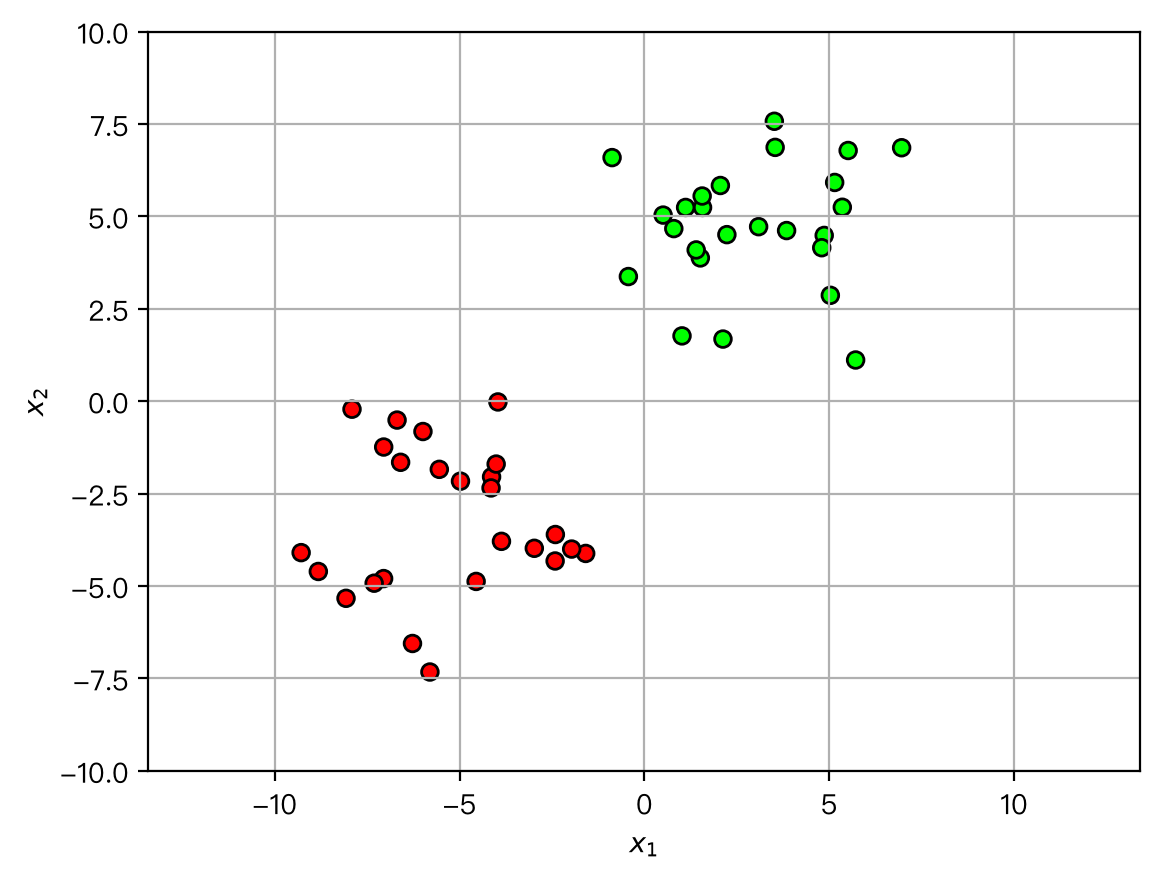

In [3]:
lsdatafig

# 哪一条分离直线最好？
- 能够将数据正确分开的解有很多个。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>只求“分对”无法在多条可行边界中做选择，SVM 额外引入了间隔准则。</div>


In [4]:
def drawplane(w, b=None, c=None, wlabel=None, poscol=None, negcol=None, lw=2, ls='k-', label=None):
    # w^Tx + b = 0
    # w0 x0 + w1 x1 + b = 0
    # x1 = -w0/w1 x0 - b / w1

    # OR
    # w^T (x-c) = 0 = w^Tx - w^Tc  --> b = -w^Tc
    if c is not None:
        b = -sum(w*c)
    
    # 直线
    if (abs(w[0])>abs(w[1])):   # 竖直线
        x0 = array([-30,30])
        x1 = -w[0]/w[1] * x0 - b / w[1]
    else:                       # 水平线
        x1 = array([-30,30])
        x0 = -w[1]/w[0] * x1 - b / w[0]
    
    # 填充正半空间或负半空间
    #if (poscol):
    #    polyx = [x0[0], x0[-1], x0[-1], x0[0]]
    #    polyy = [x1[0], x1[-1], x1[0], x1[0]]
    #    plt.fill(polyx, polyy, poscol, alpha=0.2)
    # 
    #if (negcol):
    #    polyx = [x0[0], x0[-1], x0[0], x0[0]]
    #    polyy = [x1[0], x1[-1], x1[-1], x1[0]]
    #    plt.fill(polyx, polyy, negcol, alpha=0.2)

    if (poscol) or (negcol):
        polyx = [x0[0], x0[-1], x0[-1], x0[0]]
        polyy = [x1[0], x1[-1], x1[0], x1[0]]
        f = sum(w*[polyx[2], polyy[2]])+b
        if (f>0) and (poscol):
            plt.fill(polyx, polyy, poscol, alpha=0.2)
        if (f<0) and (negcol):
            plt.fill(polyx, polyy, negcol, alpha=0.2)
    
        polyx = [x0[0], x0[-1], x0[0], x0[0]]
        polyy = [x1[0], x1[-1], x1[-1], x1[0]]
        f = sum(w*[polyx[2], polyy[2]])+b
        if (f>0) and (poscol):
            plt.fill(polyx, polyy, poscol, alpha=0.2)
        if (f<0) and (negcol):
            plt.fill(polyx, polyy, negcol, alpha=0.2)

    # 绘制直线
    plt.plot(x0, x1, ls, lw=lw, label=label)

    # 向量 w
    if (wlabel):
        xp = array([0, -b/w[1]])
        xpw = xp+w
        plt.arrow(xp[0], xp[1], w[0], w[1], width=0.01)
        plt.text(xpw[0]-0.5, xpw[1], wlabel)

In [5]:
seplinefig = plt.figure()
ws = array([[1,0.1], [0.1,1], [1,1.5], [1.5,1]])
bs = array([0.9, -1, 2, 2.5])

for i in range(len(bs)):
    plt.subplot(2,2,i+1)
    plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
    drawplane(ws[i,:], bs[i], poscol='g', negcol='r')
    plt.axis('equal'); plt.axis(axbox); plt.grid(True)
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])    
    
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


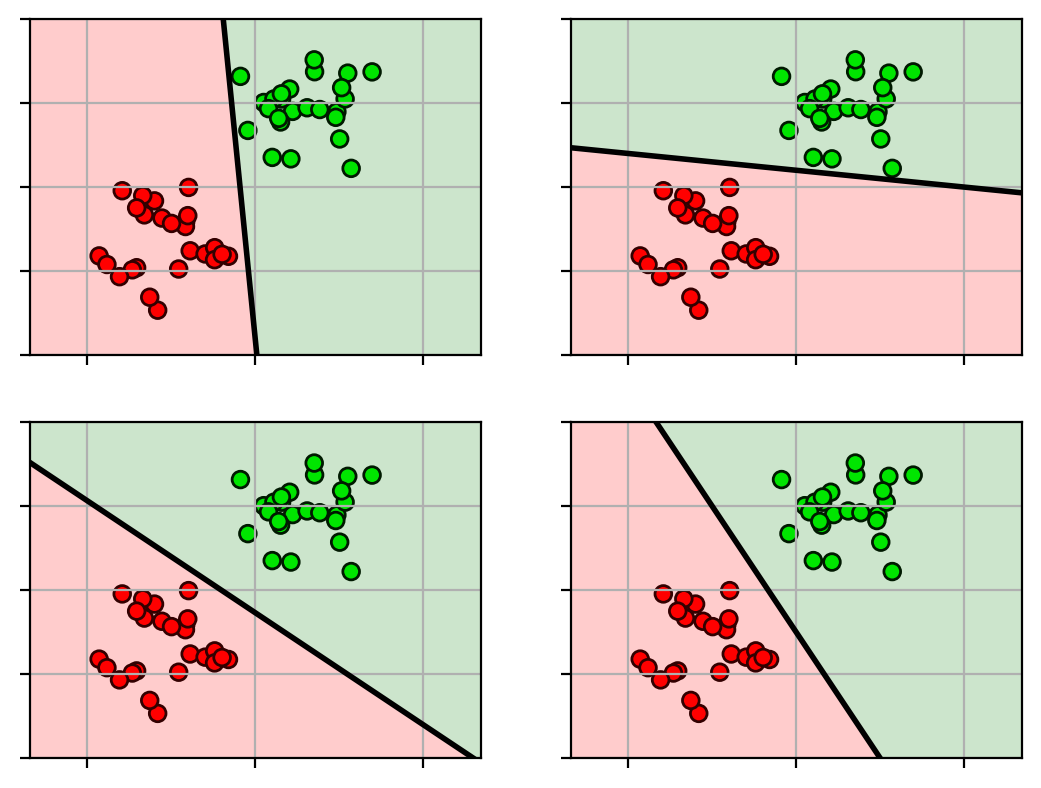

In [6]:
seplinefig

# 最大间隔
- 将分离直线与最近样本点之间的空间定义为**间隔**。
  - 可以把它理解为：对权重 $\mathbf{w}$ 的估计误差所留出的“容错空间”。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>间隔越大，决策边界对参数误差和样本扰动通常越稳健。</div>


In [7]:
def drawmargin(w,b,xmarg=None, label=None):
    wnorm = w / sqrt(sum(w**2))
    if xmarg is None:
        # 计算间隔上的一个点
        dm = 1 / sqrt(sum(w**2))
        xpt  = array([1,-w[0]/w[1]-b/w[1]])
        # 然后找到另一侧间隔（假设由 SVM 学得）
        xmarg = xpt + dm*wnorm
        xmarg2 = xpt - dm*wnorm
    else:
        # 计算到间隔的距离
        dm = (sum(w*xmarg)+b) / sqrt(sum(w**2))
        # 移动到决策平面的另一侧
        xmarg2 = xmarg - 2*dm*wnorm

    drawplane(w, c=xmarg, ls='k--', lw=1, label=label)
    drawplane(w, c=xmarg2, ls='k--', lw=1)

In [8]:
w = array([1.5,1])
b = 2.5

# 计算到间隔的距离
d = abs(dot(X,w.T) + b)
mmi = argmin(d)
x0 = X[mmi,:]

margfig = plt.figure()
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
drawplane(w, b, poscol='g', negcol='r', label='决策边界')
plt.plot(x0[0], x0[1], 'ko', fillstyle='none', markeredgewidth=2)
drawmargin(w,b,x0, label='间隔')
plt.axis('equal'); plt.axis(axbox); plt.grid(True)    
leg = plt.legend(loc='lower right' ,fontsize=10)
leg.get_frame().set_facecolor('white') 
plt.annotate(text='间隔点', xy=x0, xytext=(-12.5,2.0), 
             arrowprops=dict(facecolor='black', width=2, shrink=0.1, headwidth=6))
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


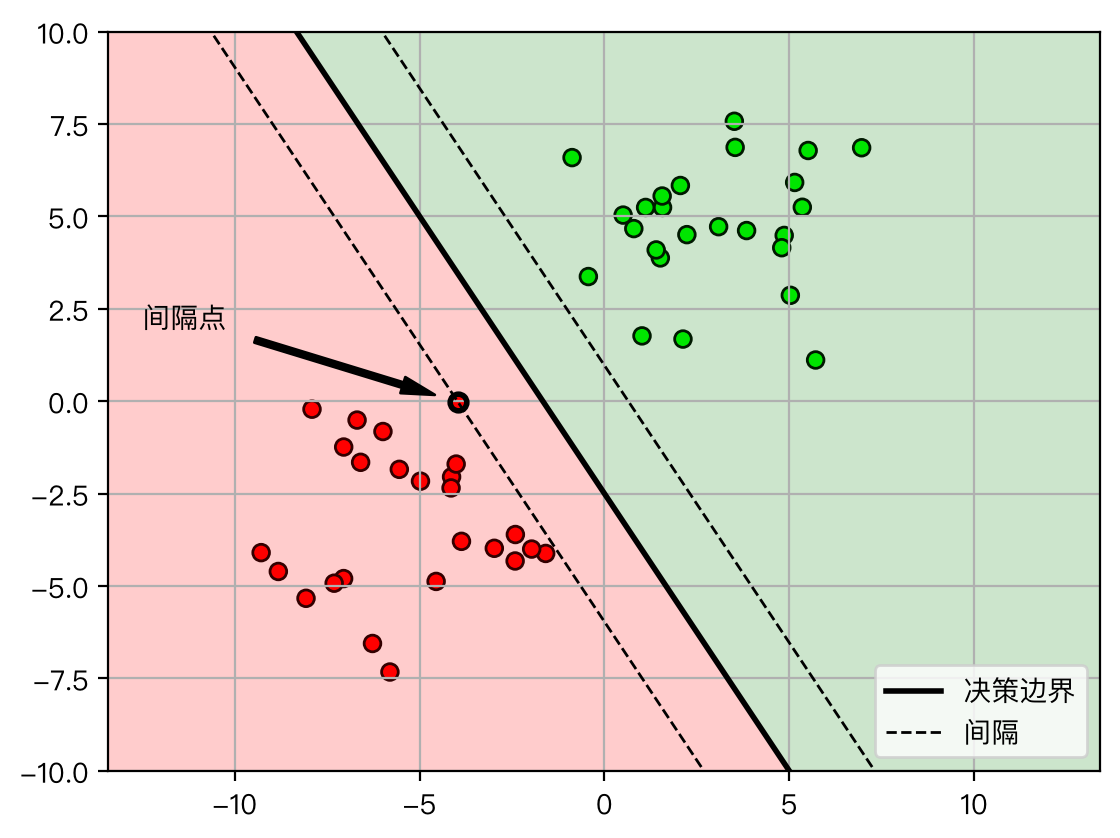

In [9]:
margfig

- **核心思想：**最好的分离直线是使间隔**最大**的直线。
  - 也就是让最近的样本点与决策边界之间的距离尽可能大。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>最大间隔是 SVM 与逻辑回归在训练原则上的核心区别。</div>


In [10]:
margfigs = plt.figure()
for i in range(len(bs)):
    w = ws[i,:]
    b = bs[i]
    d = abs(dot(X,w.T) + b)
    mmi = argmin(d)
    x0 = X[mmi,:]

    plt.subplot(2,2,i+1)
    plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
    drawplane(w, b, poscol='g', negcol='r')
    drawmargin(w, b, x0)
    plt.axis('equal'); plt.axis(axbox); plt.grid(True)
    
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


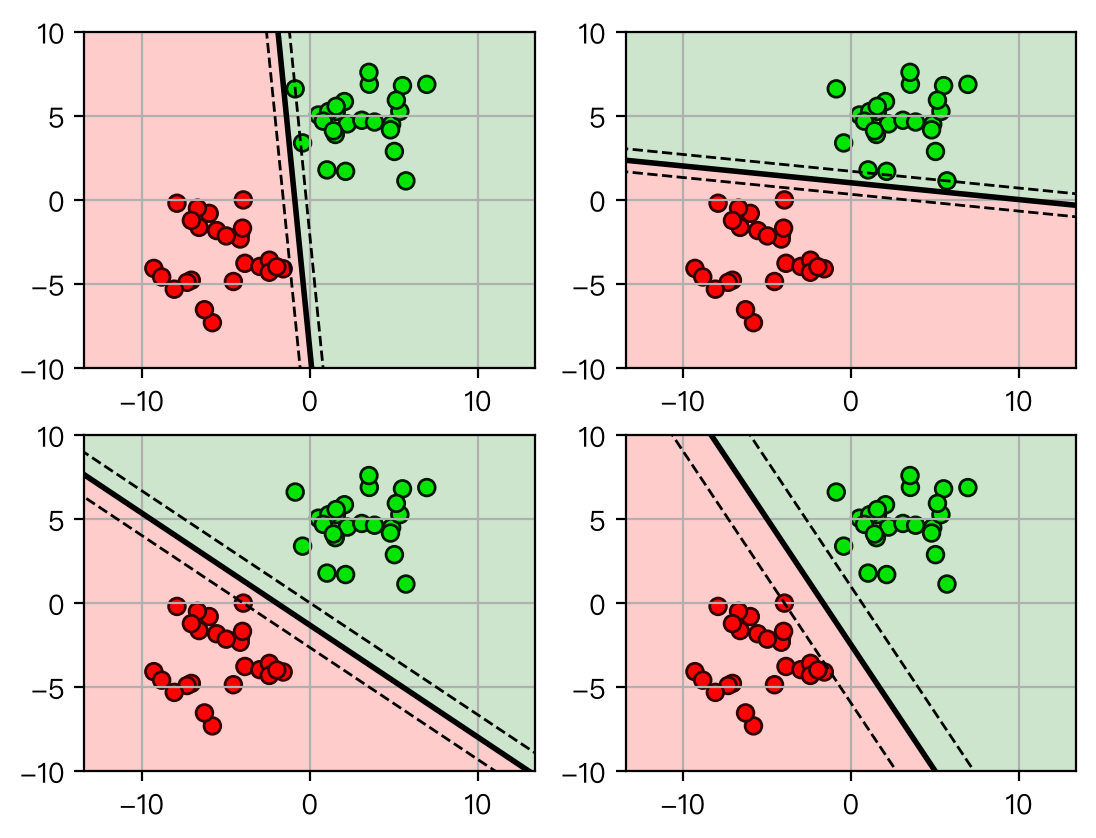

In [11]:
margfigs

- **最优解的性质：**
  - 根据对称性，决策边界两侧应各至少有一个间隔点。
    - 如果只有一侧存在间隔点，边界还可以向另一侧移动，从而进一步扩大间隔。
  - 位于间隔边界上的点称为**支持向量**：
    - 它们“支撑”并确定了间隔的位置。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>最终边界主要由最靠近边界的少量支持向量决定。</div>


In [12]:
# 拟合 SVM（kernel 指定决策面类型，后文详述）
clf = svm.SVC(kernel='linear', C=inf)
clf.fit(X, Y)

def plot_svm(clf, axbox, mycmap, showleg=True):
    # 获取直线参数
    w = clf.coef_[0]
    b = clf.intercept_[0]

    drawplane(w, b, poscol='g', negcol='r', label='决策边界')
    drawmargin(w, b, label='间隔')
    plt.plot(clf.support_vectors_[:,0], clf.support_vectors_[:,1],
         'ko',fillstyle='none', markeredgewidth=2, label='支持向量')
    plt.grid(True); plt.axis('equal'); plt.axis(axbox);
    if showleg:
        leg = plt.legend(loc='lower right', fontsize=10)
        leg.get_frame().set_facecolor('white') 
        
    
maxmfig = plt.figure()
plot_svm(clf, axbox, mycmap)
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
plt.close()




Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


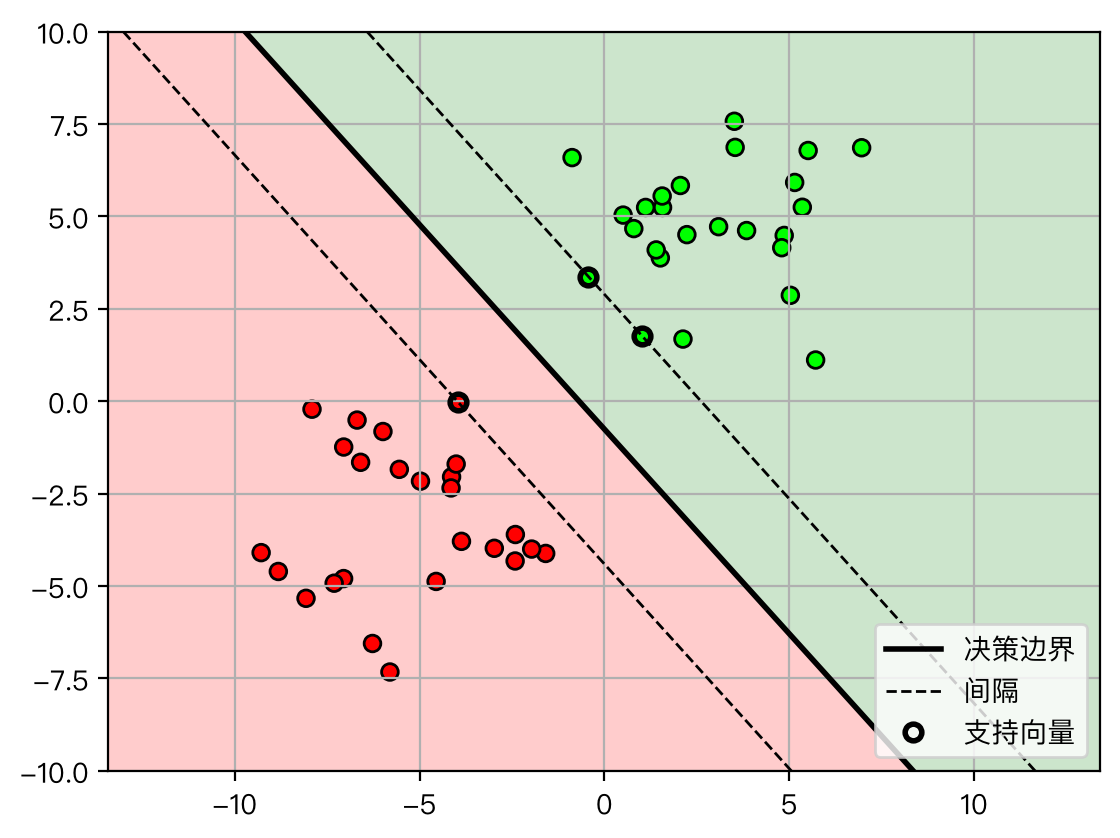

In [13]:
maxmfig

# 为什么最大化间隔有好处？
- 真实的 $\mathbf{w}$ 存在不确定性：
  - 在保持所有样本正确分类的同时，最大间隔允许 $\mathbf{w}$ 有最大的误差容忍度。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>这是一种稳健性解释：边界有轻微偏移时，宽间隔更不容易改变预测。</div>


In [14]:
maxmfigw = plt.figure()
plot_svm(clf, axbox, mycmap, showleg=False)
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')

w = clf.coef_[0]
b = clf.intercept_[0]
for i in range(10):
    w2 = w + 0.05*random.standard_normal(w.shape)
    b2 = b + 0.2*random.standard_normal(b.shape)
    drawplane(w2, b2, lw=0.5, ls='b-')
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


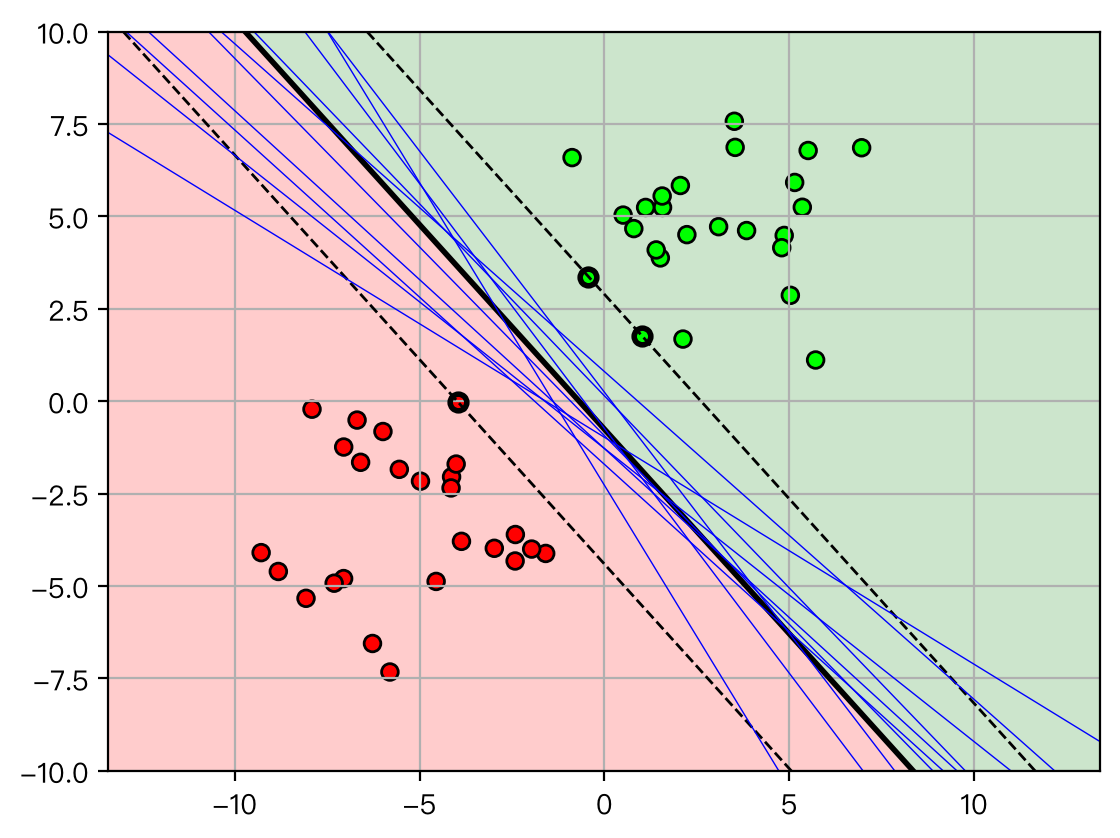

In [15]:
maxmfigw

- 数据点本身也存在不确定性：
  - 在保持所有点正确分类的同时，最大间隔允许样本点发生更大的扰动。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>如果训练点含有测量噪声，宽间隔可为样本位置变化留出空间。</div>


In [16]:
maxmfigp = plt.figure()
plot_svm(clf, axbox, mycmap)
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
plt.scatter(X[:,0], X[:,1], s=500, alpha=0.5, color='gray')
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


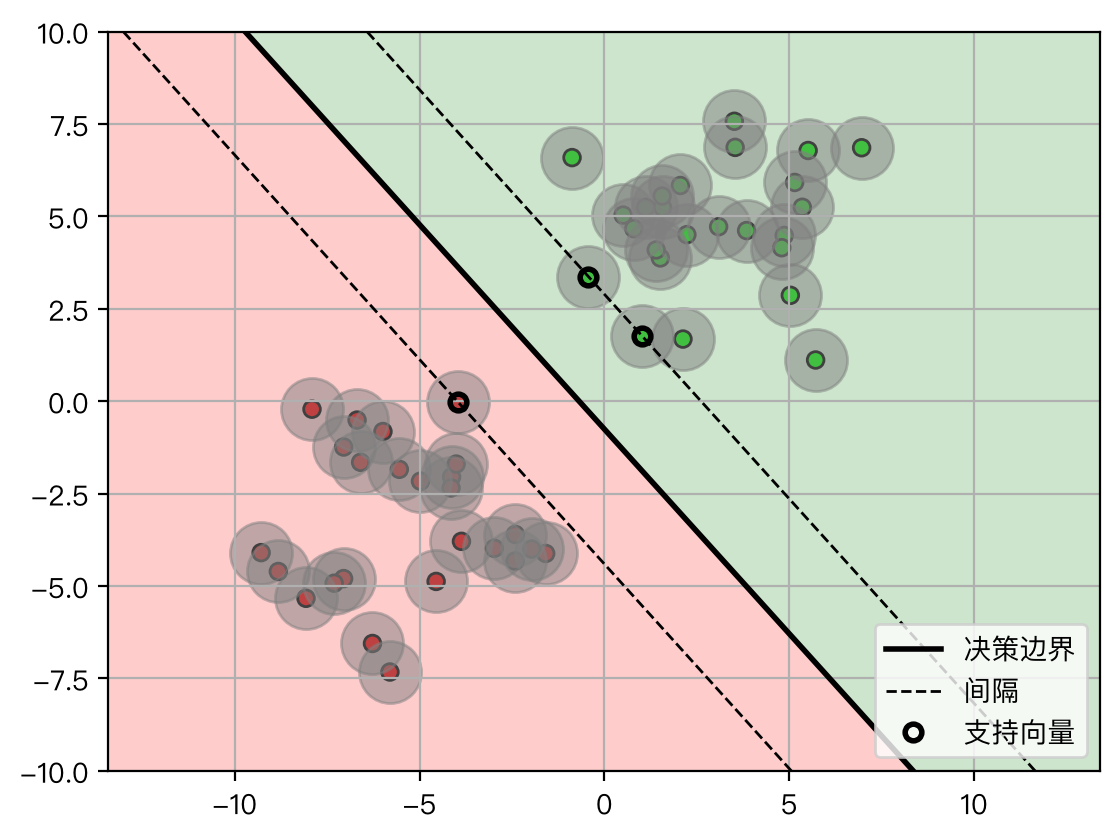

In [17]:
maxmfigp

# SVM 训练
- 给定训练集 $\{\mathbf{x}_i,y_i\}_{i=1}^N$。
- 首先定义间隔距离：
  - 点 $\mathbf{x}_i$ 到超平面的距离：
  $$d_i = \frac{|f(\mathbf{x}_i)|}{||\mathbf{w}||}$$
  - 间隔距离是所有样本距离的最小值：
  $$\gamma = \min_i \frac{|f(\mathbf{x}_i)|}{||\mathbf{w}||}$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>几何间隔是“最近样本到超平面的垂直距离”。</div>


In [18]:
def draw_dist(X, w, b, justmargin=False):
    wu = sqrt(w@w)
    d = (X@w + b) / wu
    Xo = w*d[:,newaxis] / wu
    Xp = X-Xo
    #plt.scatter(Xp[:,0], Xp[:,1])
    if not justmargin:
        for xp,x in zip(Xp,X):
            plt.plot([xp[0], x[0]], [xp[1], x[1]], ':b', lw=0.5)
    mm = amin(abs(d))
    for i,myd in enumerate(abs(d)):
        if abs(myd-mm) <= .001*mm:
            plt.plot([Xp[i,0], X[i,0]], [Xp[i,1],X[i,1]], 'b-', label="间隔距离 $\gamma$")
    #mmd = plt.plot([Xp[mmi,0], X[mmi,0]], [Xp[mmi,1],X[mmi,1]], 'b-', label="间隔距离 $\gamma$")
    

In [19]:
dfig = plt.figure()
w = ws[3,:]
b = bs[3]
d = abs(dot(X,w.T) + b)
mmi = argmin(d)
x0 = X[mmi,:]

plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
drawplane(w, b, poscol='g', negcol='r')
drawmargin(w, b, x0)
draw_dist(X, w, b)
plt.grid(True)
plt.axis('equal')
plt.axis(axbox);
plt.legend()
    
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


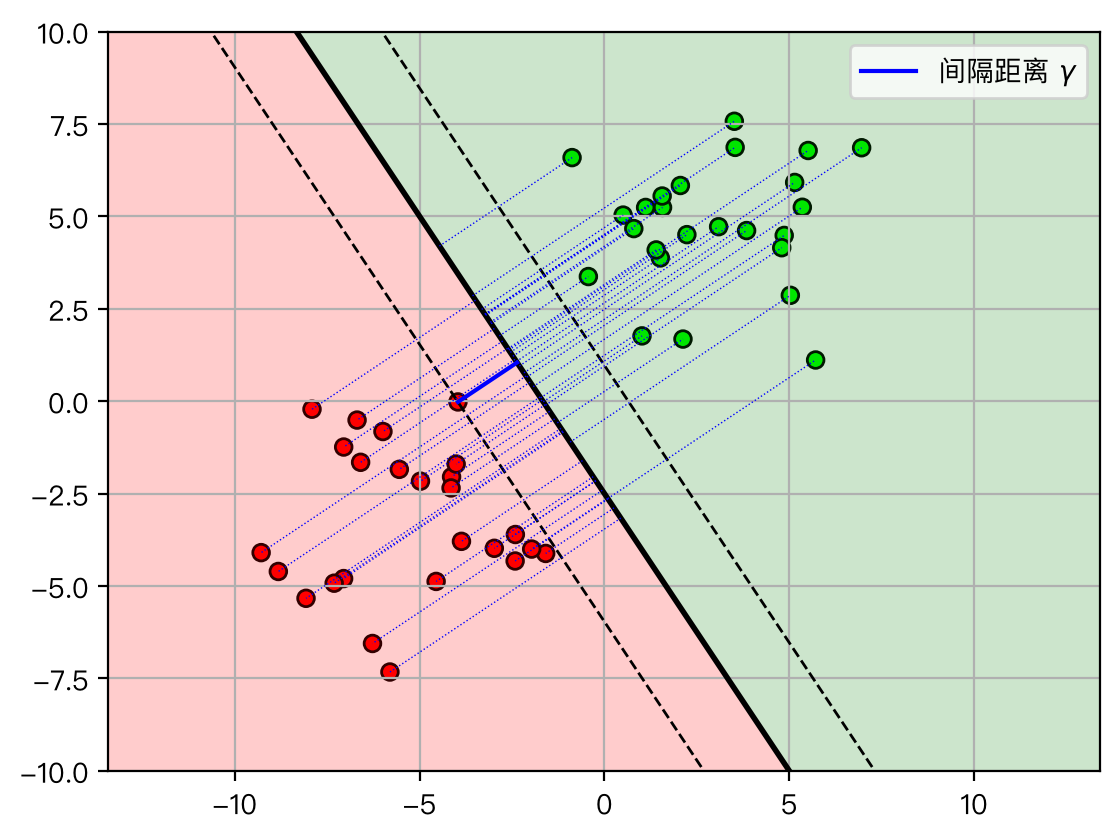

In [20]:
dfig

- 超平面参数 $\mathbf{w}$ 同时出现在分子和分母中：
  - $\gamma = \min_i \frac{|f(\mathbf{x}_i)|}{||\mathbf{w}||}= \min_i \frac{|\mathbf{w}^T\mathbf{x}_i+b|}{||\mathbf{w}||}$
- 改变 $\mathbf{w}$ 的长度不会改变间隔距离：
  - $\hat{\mathbf{w}} = a\mathbf{w}$，$\hat{b} = ab$。
  - $\frac{|\hat{\mathbf{w}}^T\mathbf{x}_i+\hat{b}|}{||\hat{\mathbf{w}}||} = \frac{|a\mathbf{w}^T\mathbf{x}_i+ab|}{||a\mathbf{w}||} = \frac{|\mathbf{w}^T\mathbf{x}_i+b|}{||\mathbf{w}||}$。
- 间隔距离由 $\mathbf{w}$ 的方向决定，而不是由它的长度决定。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>同时缩放权重和偏置不改变决策边界，所以必须加入一个尺度约定。</div>


# 归一化
- 由于 $\mathbf{w}$ 的长度不影响边界，可以对 $\mathbf{w}$ 选择一种归一化方式。
- 有两种可能：
  1. 令分母为 1：$||\mathbf{w}|| = 1$。
    - $\mathbf{w}$ 变成单位范数向量。
  2. 令分子的最小值为 1：$\min_i |f(\mathbf{x}_i)|=1$。
    - 间隔上的样本满足 $f(\mathbf{x}_i)=1$。
- 哪种归一化更方便？

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>选择第二种归一化后，间隔可直接写成权重范数的倒数。</div>


# SVM 优化问题
- 选择第二种归一化：
  - 约束：$\min_i |f(\mathbf{x}_i)|=1$。
  - 间隔：$\gamma = \frac{1}{||\mathbf{w}||}$。
- 最大化间隔：
  $$ (\hat{\mathbf{w}},b) = \mathop{\mathrm{argmax}}_{\mathbf{w},b} \frac{1}{||\mathbf{w}||} \quad \text{s.t.}\ \min_i |f(\mathbf{x}_i)|=1 $$
- 将目标取倒数，转化为最小化问题：
  $$ (\hat{\mathbf{w}},b) = \mathop{\mathrm{argmin}}_{\mathbf{w},b} \frac{1}{2}||\mathbf{w}||^2 \quad \text{s.t.}\ \min_i |f(\mathbf{x}_i)|=1 $$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>最大化间隔与最小化权重的平方范数等价，后者是更方便的凸优化形式。</div>


- 注意：如果所有样本都分类正确：
  - 对于 $y_i=1$ 的样本，$f(\mathbf{x}_i)>0$。
  - 对于 $y_i=-1$ 的样本，$f(\mathbf{x}_i)<0$。
- 因此，约束 $\min_i |f(\mathbf{x}_i)| = 1$ 可改写为：
  - $\min_i y_i f(\mathbf{x}_i) = 1$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>乘积 `y·f(x)` 同时编码了分类是否正确以及到边界的相对位置。</div>


- 更仔细地看：
  - 原约束 $\min_i y_if(\mathbf{x}_i)=1$ 表示所有样本中的最小值为 1。
  - 等价约束为 $y_if(\mathbf{x}_i) \geq 1, \forall i$。
    - 如果所有样本都严格大于 1，那么在最小化 $||\mathbf{w}||$ 时，$\mathbf{w}$ 还可以继续缩小，直到至少一个样本满足等号。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>在最优解上至少有一个约束取等号，否则还能继续缩小权重。</div>


# SVM 训练目标
- 给定训练集 $\{\mathbf{x}_i,y_i\}_{i=1}^N$，求解：
  $$ \begin{aligned}\mathop{\mathrm{argmin}}_{\mathbf{w},b} &\frac{1}{2} \mathbf{w}^T\mathbf{w}\\\mathrm{s.t.}~&y_i f(\mathbf{x}_i)\geq 1,\quad \forall i\end{aligned}$$
  - 目标函数最小化间隔距离的倒数，即最大化间隔。
  - 不等式约束保证所有样本位于间隔边界上或间隔之外。
    - 间隔上的样本满足 $y_if(\mathbf{x}_i)=1$。
    - 约束也可写为 $y_i (\mathbf{w}^T\mathbf{x}_i+b) \geq 1$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>目标函数控制模型复杂度，约束则保证硬间隔下所有样本都分类正确。</div>


# 约束优化回顾
- 考虑带不等式约束的优化问题：
$$ \min_{\mathbf{x}} f(\mathbf{x})\ \text{s.t.}\ g(\mathbf{x}) \geq 0$$
  - $f(\mathbf{x})$ 是目标函数；在 SVM 中对应间隔的倒数。
  - $g(\mathbf{x})$ 是约束函数；在 SVM 中对应间隔约束。

<center><img width="500" src="imgs/fmin.png"></center>

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>拉格朗日方法把“带约束优化”转换成对目标与约束的联合分析。</div>


- 使用拉格朗日乘子求解：
  - 引入拉格朗日乘子 $\lambda \geq 0$。
  - 构造拉格朗日函数 $L(\mathbf{x},\lambda) = f(\mathbf{x}) - \lambda g(\mathbf{x})$。
  - 寻找拉格朗日函数的驻点 $(\mathbf{x}^*, \lambda^*)$：
    - 求解 $\frac{dL}{d\mathbf{x}}=0$ 和 $\frac{dL}{d\lambda}=0$。
  - 在最优解处，拉格朗日乘子反映不等式约束的状态：
    - $\lambda^*>0$ 时，$g(\mathbf{x}^*)=0$，称为“活跃约束”。
    - $\lambda^*=0$ 时，$g(\mathbf{x}^*)>0$，称为“非活跃约束”。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>乘子为正意味着对应约束正在限制最优解；乘子为零意味着它在最优点不起作用。</div>


# 对偶性
- 可以将原始问题（原问题）改写为对偶形式：
  - 对偶函数：$q(\lambda) = \min_{\mathbf{x}} L(\mathbf{x},\lambda)$。
  - 对偶问题：$\max_{\lambda\geq 0} q(\lambda)$。
- 转而求解 $\lambda$，而不是原始变量 $\mathbf{x}$。
  - 求得 $\lambda$ 后可恢复 $\mathbf{x}$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>对偶形式把未知量从超平面参数换成每个训练样本对应的乘子。</div>


- 如果优化问题是凸的：
  - 求解对偶问题与求解**原问题**等价。
  - $\min_{\mathbf{x}, g(\mathbf{x})\geq 0} f(\mathbf{x}) = \max_{\lambda\geq 0} q(\lambda)$。
- **注意：**SVM 问题是凸优化问题，因此可以得到等价的对偶问题。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>凸性保证局部最优就是全局最优，并为原问题与对偶问题的等价提供基础。</div>


# 拉格朗日乘子与 SVM
- 为每个约束引入一个拉格朗日乘子 $\alpha_i$：
  $$ L(\mathbf{w}, \alpha) = \frac{1}{2} \mathbf{w}^T\mathbf{w}- \sum_i \alpha_i [y_i(\mathbf{w}^T\mathbf{x}_i+b)-1] $$
- 拉格朗日乘子可以指示哪些点位于间隔上：
  - 若 $\alpha_i=0$，则 $y_i(\mathbf{w}^T\mathbf{x}_i+b)>1$，样本位于间隔之外。
  - 若 $\alpha_i>0$，则 $y_i(\mathbf{w}^T\mathbf{x}_i+b)=1$，样本位于间隔上，即支持向量。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>非零乘子对应的样本就是支持向量，这是 SVM 解具有稀疏性的原因。</div>


# SVM 对偶问题
- SVM 可改写为以下对偶问题：
$$\mathop{\mathrm{argmax}}_{\alpha} \sum_i \alpha_i -\frac{1}{2}\sum_{i=1}^N\sum_{j=1}^N \alpha_i\alpha_j y_i y_j \mathbf{x}_i^T \mathbf{x}_j \\~~ \mathrm{s.t.} \sum_{i=1}^N \alpha_iy_i = 0, \quad \alpha_i\geq 0$$
- 新变量 $\alpha_i$ 对应于每个训练样本 $(\mathbf{x}_i,y_i)$。
  - 现在求解的是 $\boldsymbol{\alpha}$，而不是 $\mathbf{w}$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>对偶目标中训练样本只通过两两内积出现，这一点将直接导向核技巧。</div>


- 使用 $\alpha$ 恢复超平面 $\mathbf{w}$：
  - $\mathbf{w}$ 是数据点的加权组合。
  - $\mathbf{w} = \sum_{i=1}^N \alpha_i y_i \mathbf{x}_i$。
- 对新样本 $\mathbf{x}_*$ 进行分类：
  $$\begin{align}y_* &= \mathrm{sign}(\mathbf{w}^T \mathbf{x}_*+b) \\&= \mathrm{sign}(\sum_{i=1}^N \alpha_i y_i \mathbf{x}_i^T \mathbf{x}_* + b)\end{align}$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>预测只需支持向量与新样本的内积；乘子为零的样本不贡献。</div>


- $\alpha_i$ 的解释：
  - 当样本 $\mathbf{x}_i$ 不在间隔上时，$\alpha_i=0$。
  - 当样本位于间隔上或违反间隔时，$\alpha_i>0$：
    - 此时样本是支持向量。
    - $y_i\alpha_i>0$ 对应正类的间隔样本。
    - $y_i\alpha_i<0$ 对应负类的间隔样本。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>支持向量是对最终决策边界有直接影响的训练样本。</div>


# SVM 预测
- 给定一个新数据点 $\mathbf{x}_*$，使用线性函数的符号预测类别：
  - $y_* = \mathop{\mathrm{sign}} f(\mathbf{x}_*) = \mathop{\mathrm{sign}}(\mathbf{w}^T \mathbf{x}_* + b)$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>标准 SVM 输出的是决策得分和类别，不是像逻辑回归那样直接学习后验概率。</div>


# 示例
- $f(\mathbf{x})$ 定义的不同区域：
  - $f(\mathbf{x})=0$：决策边界。
  - $f(\mathbf{x})=\pm1$：正、负间隔边界。
  - $f(\mathbf{x})>1$：被正确分为类别 1 的点。
  - $f(\mathbf{x})<-1$：被正确分为类别 -1 的点。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>得分为零是决策边界，得分为正负一是两条间隔边界。</div>


In [21]:
# 拟合 SVM（kernel 指定决策面类型，后文详述）
clf = svm.SVC(kernel='linear', C=inf)
clf.fit(X, Y)

egsvmfig = plt.figure()
plot_svm(clf, axbox, mycmap)
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
draw_dist(X, clf.coef_[0], clf.intercept_[0], justmargin=True)
plt.text(-9.5,7.5, '$f(\mathbf{x})=0$', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
plt.text(-5,7.5, '$f(\mathbf{x})=1$', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
plt.text(-12,5, '$f(\mathbf{x})=-1$', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
plt.text(7,5, '$f(\mathbf{x})>1$', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
plt.text(-12,-2.5, '$f(\mathbf{x})<-1$', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='white'))
plt.annotate(text='$\gamma = 1/||\mathbf{w}||$', xy=(0,1), xytext=(2.5,-2.0), 
             backgroundcolor='white', 
             arrowprops=dict(facecolor='black', width=1, shrink=0.1, headwidth=6))
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


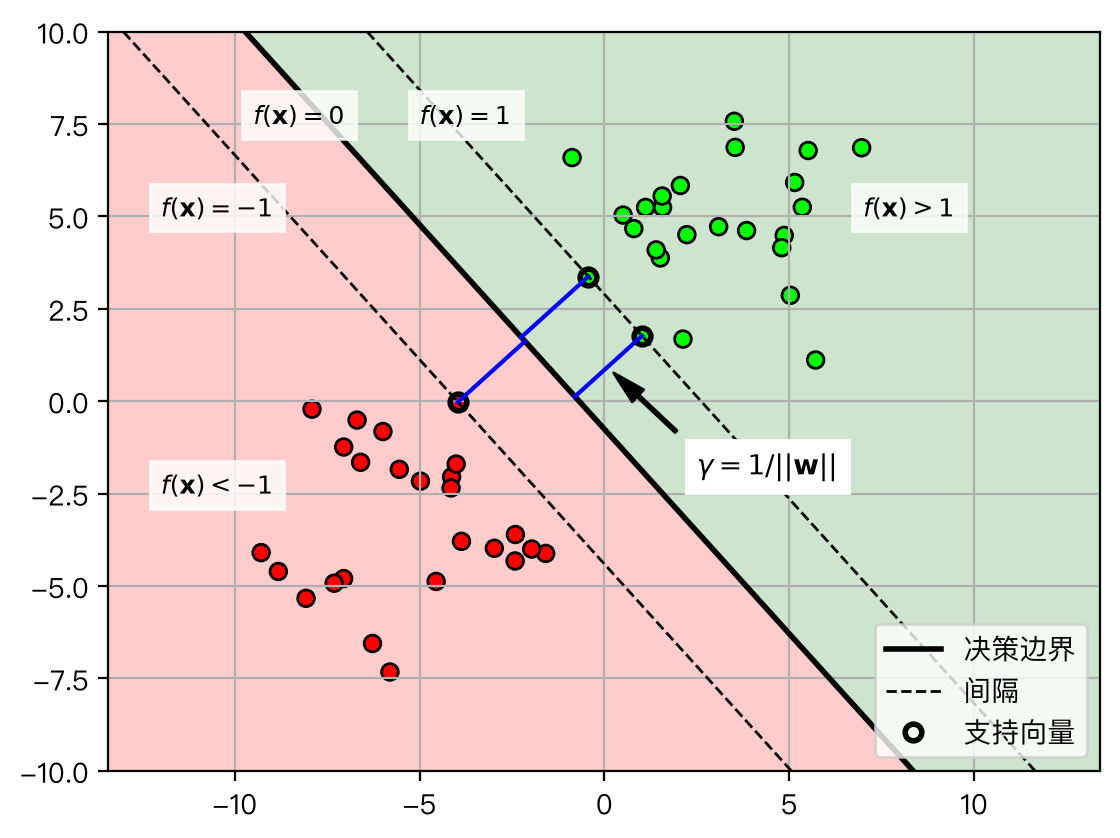

In [22]:
egsvmfig

# 如果数据不可分怎么办？
- 仍然使用同一个线性分类器，但允许一些训练样本**违反**间隔：
  - 样本可以位于间隔内，甚至被错误分类。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>软间隔的关键是接受少量违反，以换取对噪声和离群点更稳健的边界。</div>


- 定义**松弛变量** $\xi_i \geq 0$：
  - $\xi_i=0$ 表示样本位于间隔区域之外，没有松弛。
  - $\xi_i>0$ 表示样本位于间隔区域之内，存在松弛。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>松弛变量衡量每个样本对间隔约束的违反程度。</div>


In [23]:
slackfig = plt.figure(figsize=(5,5))
plot_svm(clf, axbox, mycmap, showleg=False)
plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')

xv = array([0.5, -2])
xm = xv-clf.coef_.ravel()*5.2

plt.scatter([xv[0]], [xv[1]], c=[1], cmap=mycmap, edgecolors='k')
# 存在松弛的样本点
plt.annotate(text='违反间隔', xy=xv, xytext=(4.0,-2.0), 
             backgroundcolor='white', 
             arrowprops=dict(facecolor='black', width=1, shrink=0.1, headwidth=6))

plt.annotate(text="", xy=xv, xytext=xm, 
            arrowprops=dict(arrowstyle="<->"))
plt.text(-0.2, -3.5, "$\\xi_i>0$", fontsize=12)
plt.text(-5, -7, "$\\xi_i=0$", fontsize=14)
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


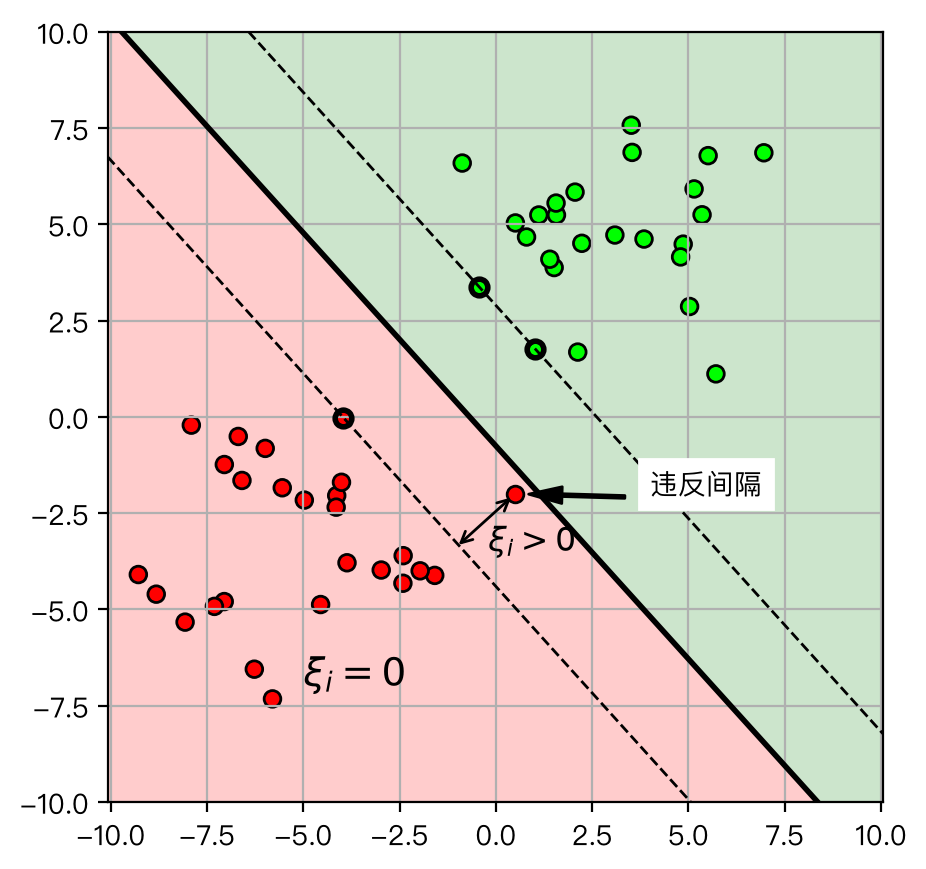

In [24]:
slackfig

- 约束现在包含松弛变量：
  - $y_i f(\mathbf{x}_i)\geq 1-\xi_i,\forall i$。
- 有两种情况：
  - $\xi_i=0$ 时，样本满足普通间隔约束 $y_i f(\mathbf{x}_i)\geq1$。
  - $\xi_i>0$ 时，样本位于间隔内，满足 $y_i f(\mathbf{x}_i)=1-\xi_i$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>松弛值大于 1 时，样本不仅进入间隔，而且可能已经被错分。</div>


# 软间隔 SVM 优化问题
- 对每个违反间隔的训练样本加入松弛惩罚：
  - 惩罚由超参数 $C$ 控制。
    - $C$ 较小：惩罚较弱，允许更多违反。
    - $C$ 较大：惩罚较强，尽量不允许违反。

$$\begin{aligned}\mathop{\mathrm{argmin}}_{\mathbf{w},b} &\frac{1}{2} \mathbf{w}^T\mathbf{w} + C\sum_{i=1}^N \xi_i \\\mathrm{s.t.}~&y_if(\mathbf{x}_i)\geq 1-\xi_i,\quad \forall i\\&\xi_i\geq 0\end{aligned}$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>参数 C 大时更重视减少训练违反；C 小时更重视宽间隔和模型简单性。</div>


In [25]:
# 生成线性不可分的随机数据
X,Y = datasets.make_blobs(n_samples=50, 
         centers=2, cluster_std=3.5, n_features=2, 
         center_box=(-5,5), random_state=4487)

Cs = [0.01, 0.1, 1, 10]
Cmargfigs = plt.figure()

for i in range(len(Cs)):
    # 拟合 SVM
    clf = svm.SVC(kernel='linear', C=Cs[i])
    clf.fit(X, Y)

    plt.subplot(2,2,i+1)
    plt.scatter(X[:,0], X[:,1], c=Y, cmap=mycmap, edgecolors='k')
    plot_svm(clf, axbox, mycmap, showleg=False)
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])
    plt.title("C="+str(Cs[i]))
    
plt.close()

- 不同 $C$ 取值的示例。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>不同 C 会同时改变间隔宽度、支持向量数量和训练误差。</div>


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


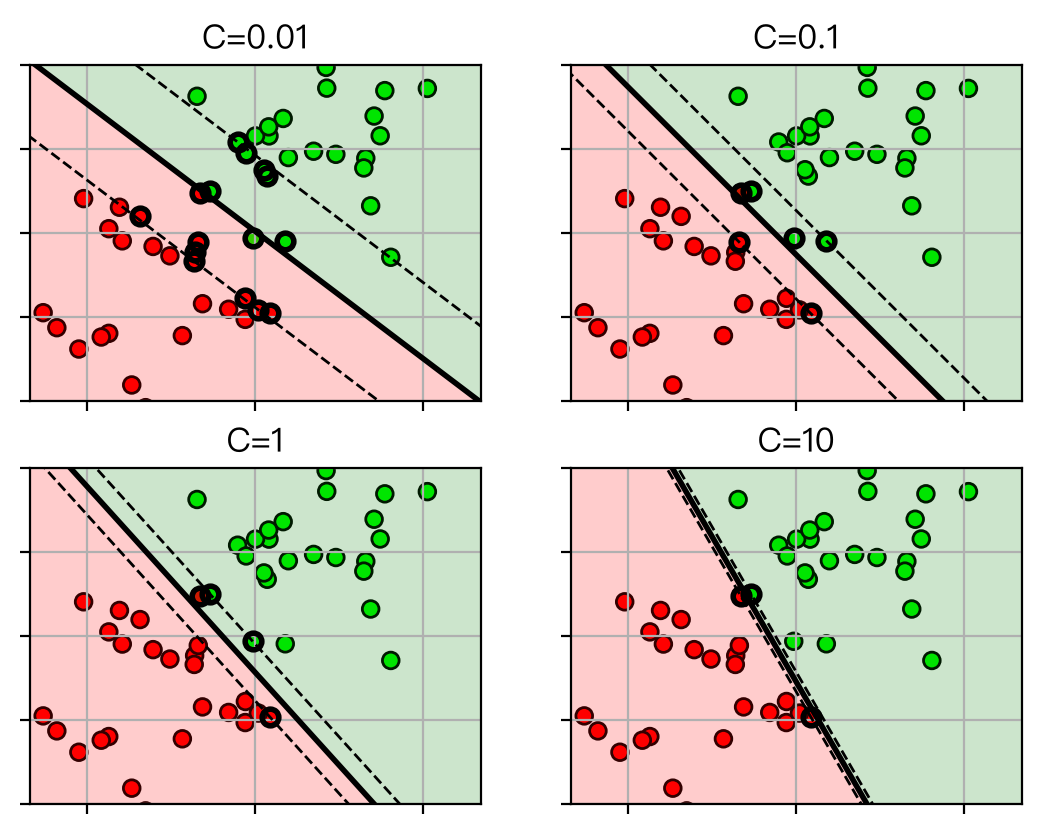

In [26]:
Cmargfigs

# 损失函数
- 经过等价变形，目标函数可写为：
$$ \mathop{\mathrm{argmin}}_{\mathbf{w},b} \frac{1}{C} \mathbf{w}^T\mathbf{w} + \sum_{i=1}^N \max(0, 1-y_i f(\mathbf{x}_i))$$
  - **合页损失（hinge loss）：**$L(z_i) = \max(0,1-z_i)$。
  - $\max(a,b)$ 返回 $a$ 与 $b$ 中较大的值。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>合页损失对间隔外且分类正确的样本为零，对间隔内或错分样本线性惩罚。</div>


In [27]:
z = linspace(-6,6,100)
logloss = log(1+exp(-z))
hingeloss = maximum(0, 1-z)
lossfig = plt.figure()
plt.plot(z,hingeloss, 'b-')

plt.plot([0,0], [0,9], 'k--')
plt.text(0,8.5, "分类错误 $\\Leftarrow$ ", ha='right', weight='bold')
plt.text(0,8.5, " $\Rightarrow$ 分类正确", ha='left', weight='bold')

plt.annotate(text="严重分错的样本\n产生较大损失", 
             xy=(-4,5), xytext=(-4.5,6.2),backgroundcolor='white',
            arrowprops=dict(arrowstyle="->"))
plt.annotate(text="靠近间隔的样本\n产生非零损失", 
             xy=(0.5,0.5), xytext=(-0.5,3.2), backgroundcolor='white',
            arrowprops=dict(arrowstyle="->"))
plt.annotate(text="位于间隔正确一侧的样本\n损失为零", 
             xy=(3,0.0), xytext=(2,1.1), backgroundcolor='white',
            arrowprops=dict(arrowstyle="->"))
plt.grid(True)
plt.xlabel('$z_i$');
plt.ylabel('损失')
plt.title('合页损失')
plt.xlim(-6,6)
plt.close()

findfont: Failed to find font weight bold, now using 600.
findfont: Failed to find font weight bold, now using 600.


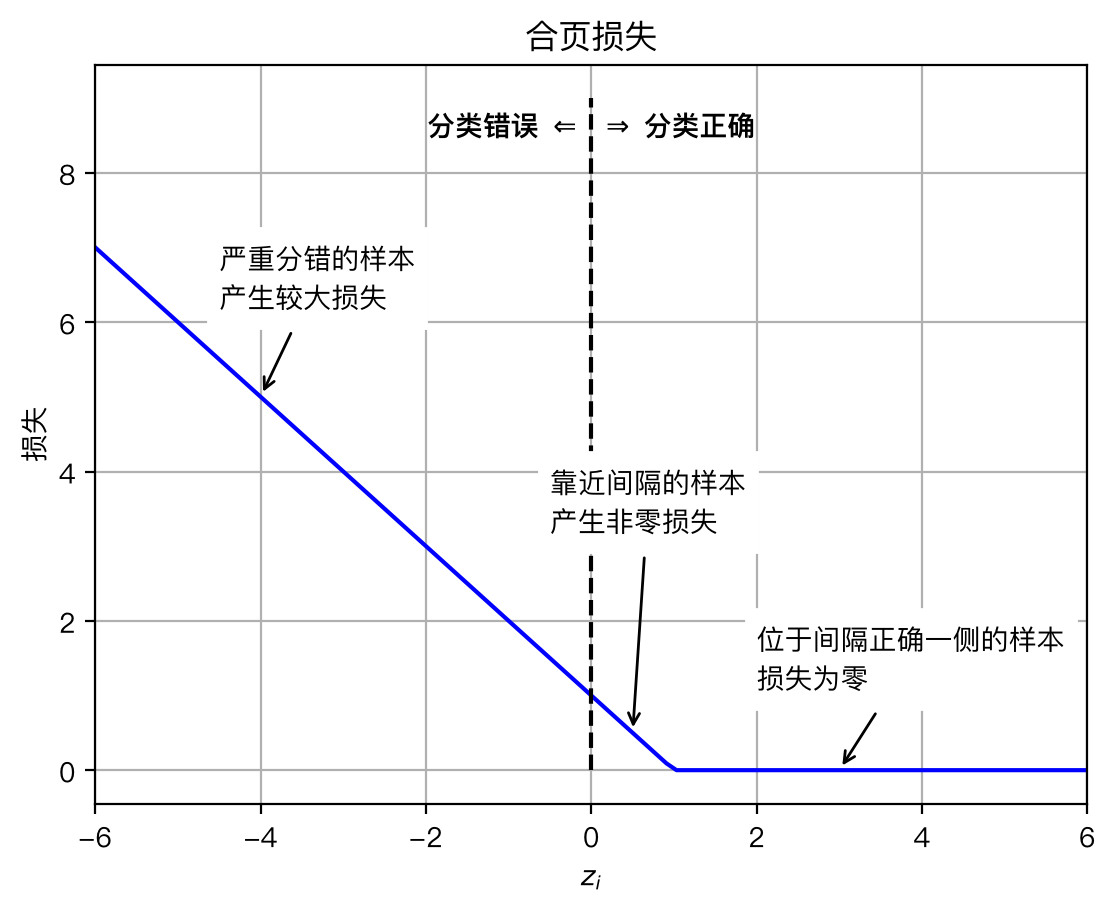

In [28]:
lossfig

# 示例：Iris 数据

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>这一部分使用 Iris 数据演示支持向量、决策边界、网格搜索和测试评估。</div>


In [29]:
# 载入 Iris 数据；每行为（花瓣长度、花萼宽度、类别）
irisdata = loadtxt('iris2.csv', delimiter=',', skiprows=1)

X = irisdata[:,0:2]  # 前两列是特征（花瓣长度、花萼宽度）
Y = irisdata[:,2]    # 第三列是类别标签（变色鸢尾=1，弗吉尼亚鸢尾=2）

print(X.shape)

(100, 2)


In [30]:
# 随机将数据划分为 50% 训练集和 50% 测试集
trainX, testX, trainY, testY = \
  model_selection.train_test_split(X, Y, 
  train_size=0.5, test_size=0.5, random_state=4487)

print(trainX.shape)
print(testX.shape)

(50, 2)
(50, 2)


In [31]:
# 使用全部训练数据和最优 C 拟合 SVM   
clf = svm.SVC(kernel='linear', C=2)
clf.fit(trainX, trainY)

# 获取直线参数
w = clf.coef_[0]
b = clf.intercept_[0]
print(w)
print(b)

[2.87200943 0.10399865]
-13.95923965217775


In [32]:
# 支持向量（位于间隔上或其内部）的样本索引
clf.support_

array([ 0,  7, 12, 31, 36, 41, 13, 20, 22, 25, 33, 46], dtype=int32)

In [33]:
axbox = [2.5, 7, 1.5, 4]
svmfig = plt.figure()
plot_svm(clf, axbox, mycmap)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
plt.title('训练数据与分类边界');
plt.close()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


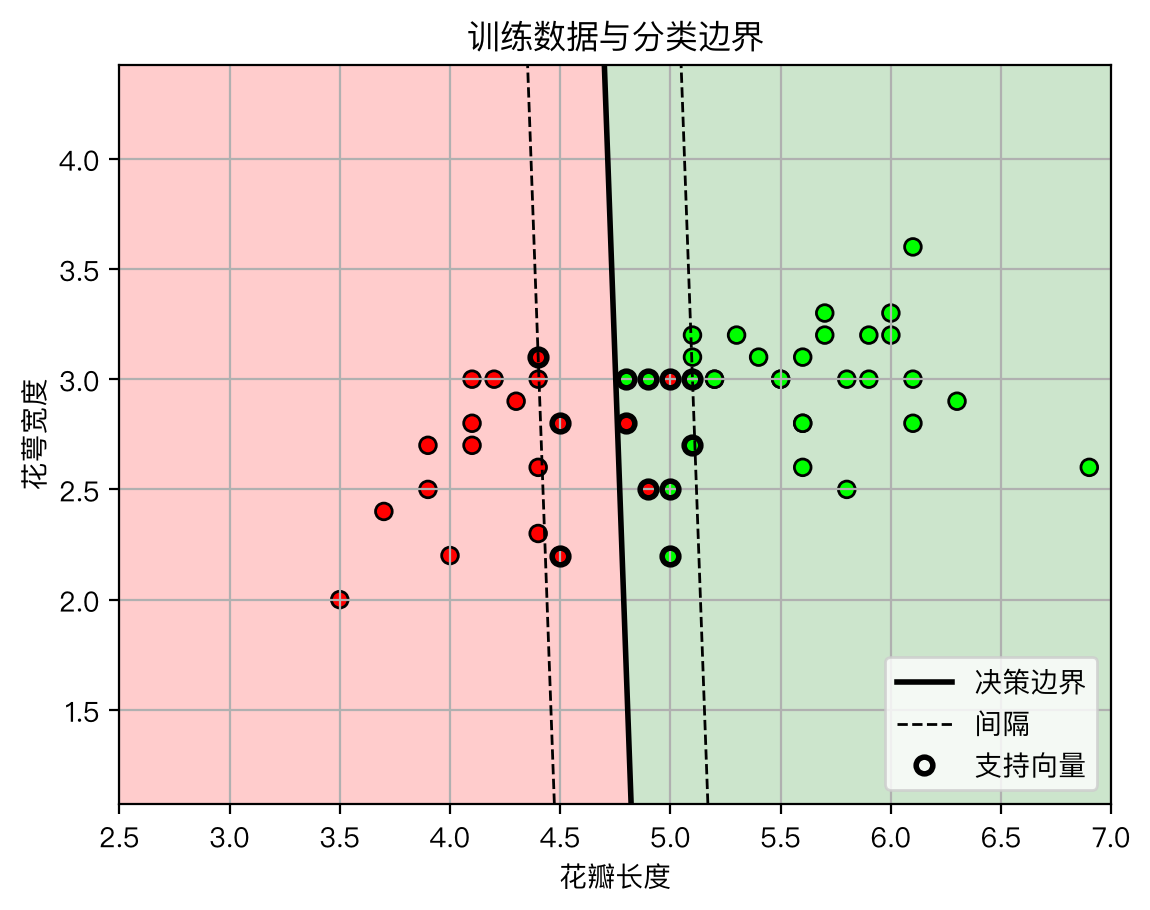

In [34]:
svmfig

- SVM 没有专用的交叉验证类。
- 使用 `GridSearchCV` 对参数列表进行交叉验证：
  - 计算每组参数的平均准确率。
  - 选择平均准确率最高的参数，并用所有训练数据重新拟合模型。
  - 可使用 `n_jobs` 指定并行任务数以加速。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>参数选择只能在训练集内部完成；最终测试集不应参与网格搜索。</div>


In [35]:
# 设置待尝试的参数列表
paramgrid = {'C': logspace(-3,3,13)}
print(paramgrid)

# 设置交叉验证对象
# 传入 SVM 对象、参数网格和交叉验证折数
# 将并行任务数设为 -1（使用所有 CPU 核）
svmcv = model_selection.GridSearchCV(svm.SVC(kernel='linear'), paramgrid, cv=5,
                                     n_jobs=-1, verbose=True)

# 运行交叉验证（对每次划分进行训练）
svmcv.fit(trainX, trainY);

{'C': array([1.00000000e-03, 3.16227766e-03, 1.00000000e-02, 3.16227766e-02,
       1.00000000e-01, 3.16227766e-01, 1.00000000e+00, 3.16227766e+00,
       1.00000000e+01, 3.16227766e+01, 1.00000000e+02, 3.16227766e+02,
       1.00000000e+03])}
Fitting 5 folds for each of 13 candidates, totalling 65 fits


In [36]:
# 显示每组参数的交叉验证得分
for m,p in zip(svmcv.cv_results_['mean_test_score'], svmcv.cv_results_['params']):
    print("平均得分={:.4f} {}".format(m,p))

平均得分=0.6200 {'C': np.float64(0.001)}
平均得分=0.6200 {'C': np.float64(0.0031622776601683794)}
平均得分=0.6200 {'C': np.float64(0.01)}
平均得分=0.6600 {'C': np.float64(0.03162277660168379)}
平均得分=0.9400 {'C': np.float64(0.1)}
平均得分=0.9600 {'C': np.float64(0.31622776601683794)}
平均得分=0.9400 {'C': np.float64(1.0)}
平均得分=0.9400 {'C': np.float64(3.1622776601683795)}
平均得分=0.9400 {'C': np.float64(10.0)}
平均得分=0.9200 {'C': np.float64(31.622776601683793)}
平均得分=0.9000 {'C': np.float64(100.0)}
平均得分=0.9000 {'C': np.float64(316.22776601683796)}
平均得分=0.9000 {'C': np.float64(1000.0)}


{'C': np.float64(0.31622776601683794)}
0.96
SVC(C=np.float64(0.31622776601683794), kernel='linear')


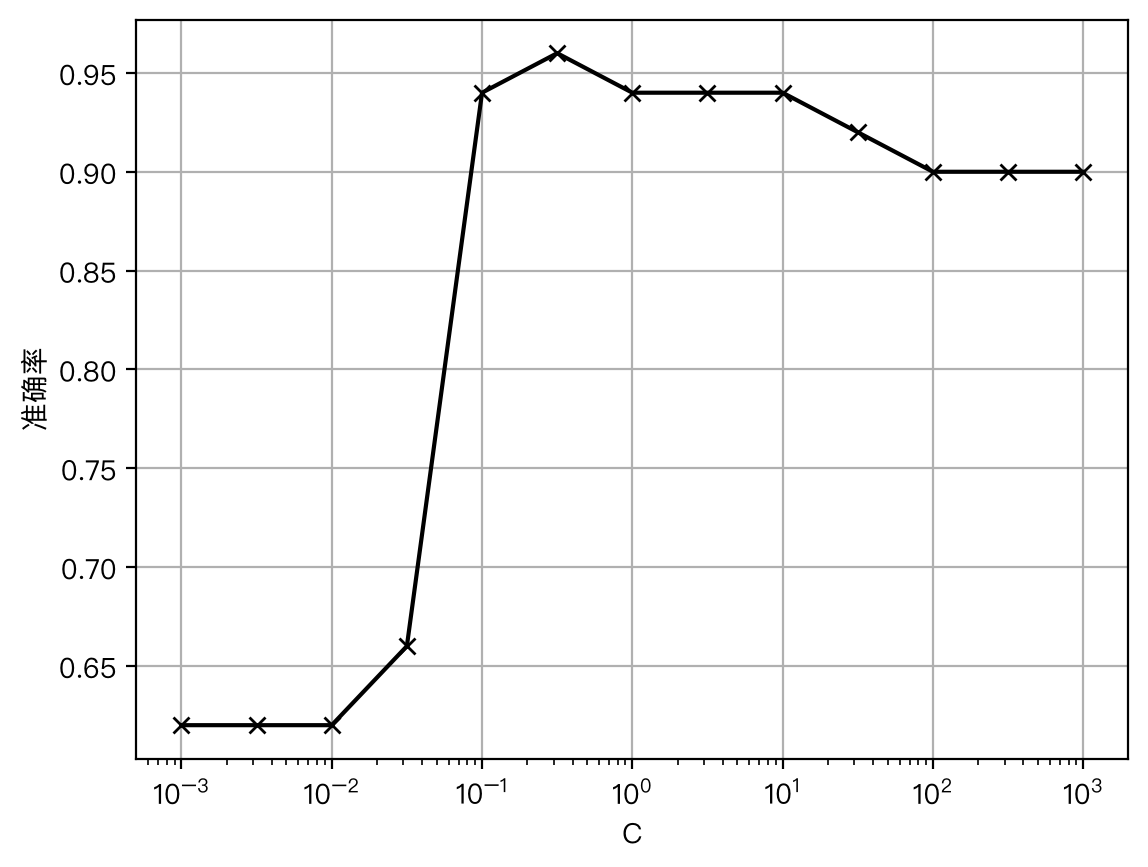

In [37]:
# 绘图
allC      = [p['C'] for p in svmcv.cv_results_['params']]
allscores = svmcv.cv_results_['mean_test_score']
    
plt.figure()
plt.semilogx(allC, allscores, 'kx-')
plt.xlabel('C'); plt.ylabel('准确率')
plt.grid(True)

# 查看最优结果和重新训练后的最优估计器
print(svmcv.best_params_)
print(svmcv.best_score_)
print(svmcv.best_estimator_)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


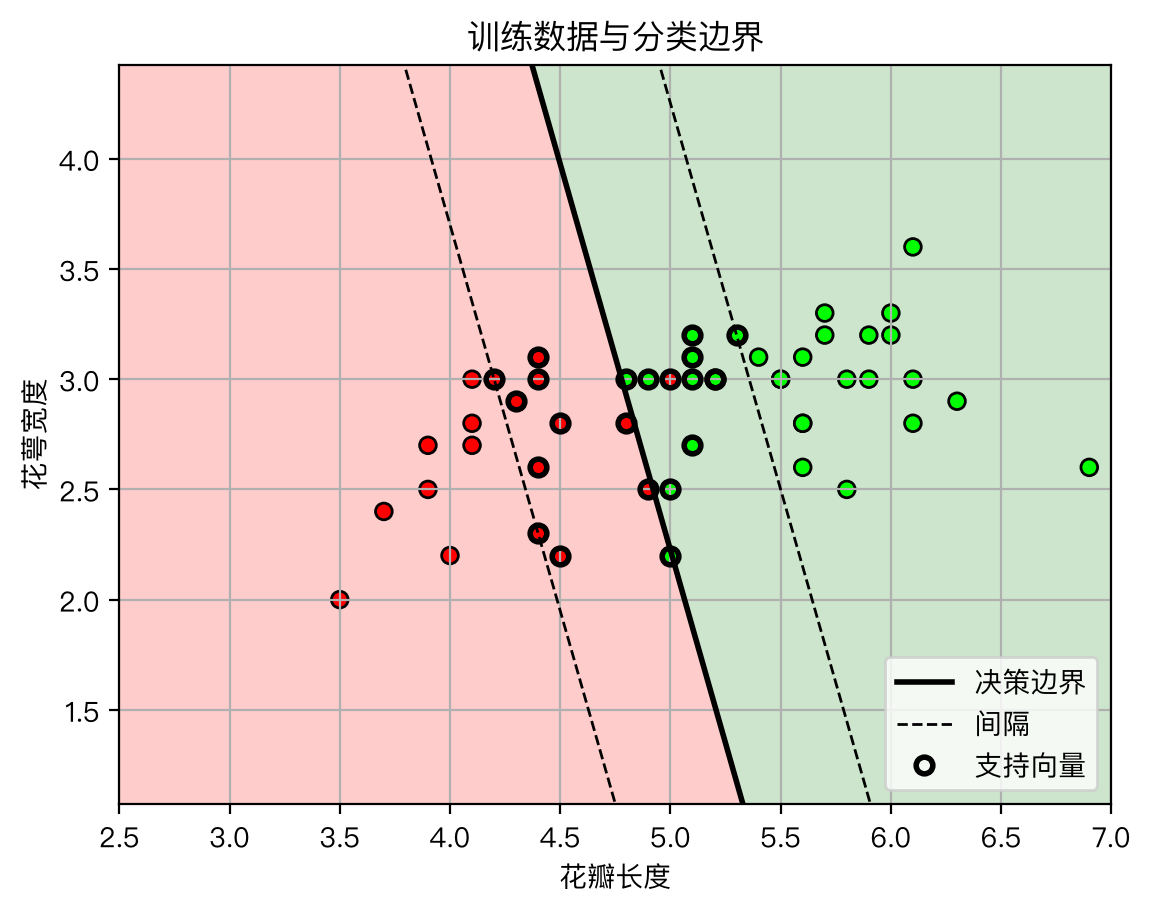

In [38]:
plt.figure()
plot_svm(svmcv.best_estimator_, axbox, mycmap)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
plt.title('训练数据与分类边界');

In [39]:
# 直接使用 svmcv 进行预测
predY = svmcv.predict(testX)

acc = metrics.accuracy_score(testY, predY)
print("测试准确率 = " + str(acc))

测试准确率 = 0.88


In [40]:
# 绘制测试数据
tsvmfig = plt.figure()
plot_svm(svmcv.best_estimator_, axbox, mycmap)
plt.scatter(testX[:,0], testX[:,1], c=testY, cmap=mycmap, marker='s', edgecolors='k')
plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
plt.title('测试数据与分类边界');
plt.close()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


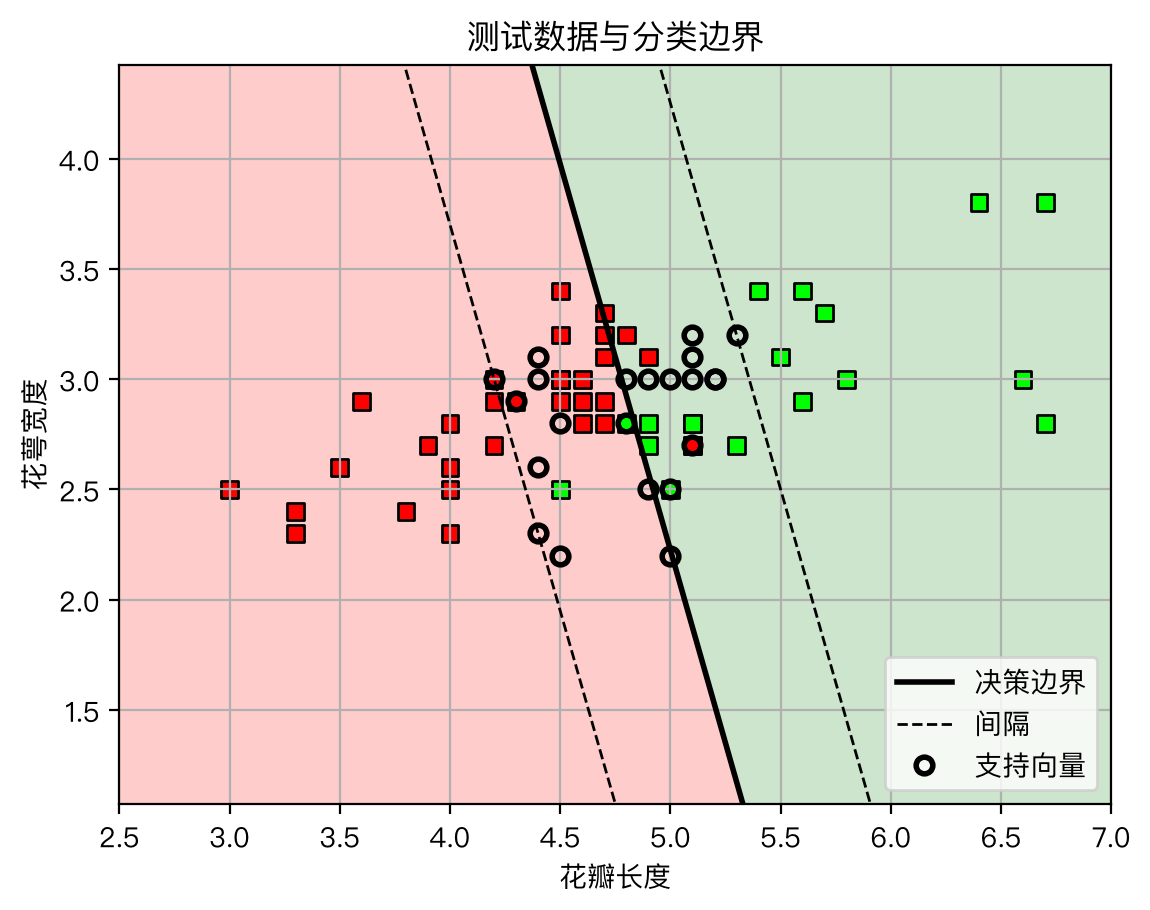

In [41]:
tsvmfig

# 多类 SVM
- scikit-learn 的 `svm.SVC` 使用“一对一”方式实现多类分类：
  - 对所有类别对训练二元分类器。
    - 三类示例：1 对 2、1 对 3、2 对 3。
  - 预测时，选择在所有二元分类器中得票最多的类别。
- 问题：
  - 类别数很多时，一对一会很慢。
  - 若有 $C$ 个类别，需要训练 $C(C-1)/2$ 个二元分类器。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>一对一需要二次数量级的分类器，类别非常多时训练成本会显著上升。</div>


# 一对其余 SVM
- 可使用 `multiclass.OneVsRestClassifier` 将任意二元分类器构造成一对其余分类器：
  - 将二元分类器作为基分类器传入。
- 对于 `GridSearchCV`，二元 SVM 被包装在一对其余类中：
  - 使用 `'estimator__C'` 指定内层 SVM 的参数 $C$。
  - `A__B` 表示待交叉验证的参数 `B` 嵌套在参数 `A` 对应的估计器中。

<img src="imgs/nestedclassifier.png" width=600>

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>嵌套估计器调参时，要用双下划线指定内层参数。</div>


In [42]:
# 载入 Iris 数据；每行为（花瓣长度、花萼宽度、类别）
irisdata = loadtxt('iris3.csv', delimiter=',', skiprows=1)

X = irisdata[:,0:2]  # 前两列是特征（花瓣长度、花萼宽度）
Y = irisdata[:,2]    # 第三列是类别标签（山鸢尾=0，变色鸢尾=1，弗吉尼亚鸢尾=2）

# 随机将数据划分为 50% 训练集和 50% 测试集
trainX, testX, trainY, testY = \
  model_selection.train_test_split(X, Y, 
  train_size=0.5, test_size=0.5, random_state=4487)

print(trainX.shape)
print(testX.shape)

(75, 2)
(75, 2)


In [43]:
msvm = multiclass.OneVsRestClassifier(svm.SVC(kernel='linear'))

# 设置参数并运行交叉验证
paramgrid = {'estimator__C': logspace(-3,3,13)}
msvmcv = model_selection.GridSearchCV(msvm, paramgrid, cv=5, n_jobs=-1, verbose=True)
msvmcv.fit(trainX, trainY)
print(msvmcv.best_params_)

Fitting 5 folds for each of 13 candidates, totalling 65 fits
{'estimator__C': np.float64(10.0)}


In [44]:
def plot_posterior3(model, axbox, mycmap, showscore=False):    
    xr = [ arange(0.8,7,0.01) , arange(1.5, 4.5, 0.01) ]
        
    # 创建用于计算决策区域的网格，
    # 然后组成一个大型 [N,2] 矩阵
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allpts = c_[xgrid0.ravel(), xgrid1.ravel()]

    P = model.predict(allpts).reshape(xgrid0.shape)

    # 计算决策得分
    if showscore:
        Z = model.decision_function(allpts)

        ZZ = Z.reshape((len(xr[1]), len(xr[0]), 3))
        ZZZ = maximum(minimum(ZZ, 1), -1)/2 + 0.5

        plt.imshow(ZZZ, origin='lower', extent=axbox, alpha=0.50,
                  cmap=mycmap, interpolation='nearest')
    else:
        plt.imshow(P, origin='lower', extent=axbox, alpha=0.50,
               cmap=mycmap, interpolation='nearest')

    #plt.contourf(xr[0], xr[1], P, levels=[0,1,2], cmap=mycmap)
    plt.contour(xr[0], xr[1], P, levels=[0.5,1.5,2.5], linestyles='dashed', colors='black')

# 显示训练数据
axbox = [0.8, 7, 1.5, 4.5]
# 创建用于显示各类别的颜色映射
mycmap = matplotlib.colors.LinearSegmentedColormap.from_list('mycmap', ["#FF0000", "#00FF00", "#0000FF"])

svm3fig = plt.figure()
plot_posterior3(msvmcv, axbox, mycmap)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.axis(axbox); plt.grid(True);
plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
plt.close()

# 三类决策边界

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>最终的多类区域是多个二元决策函数联合作用的结果。</div>


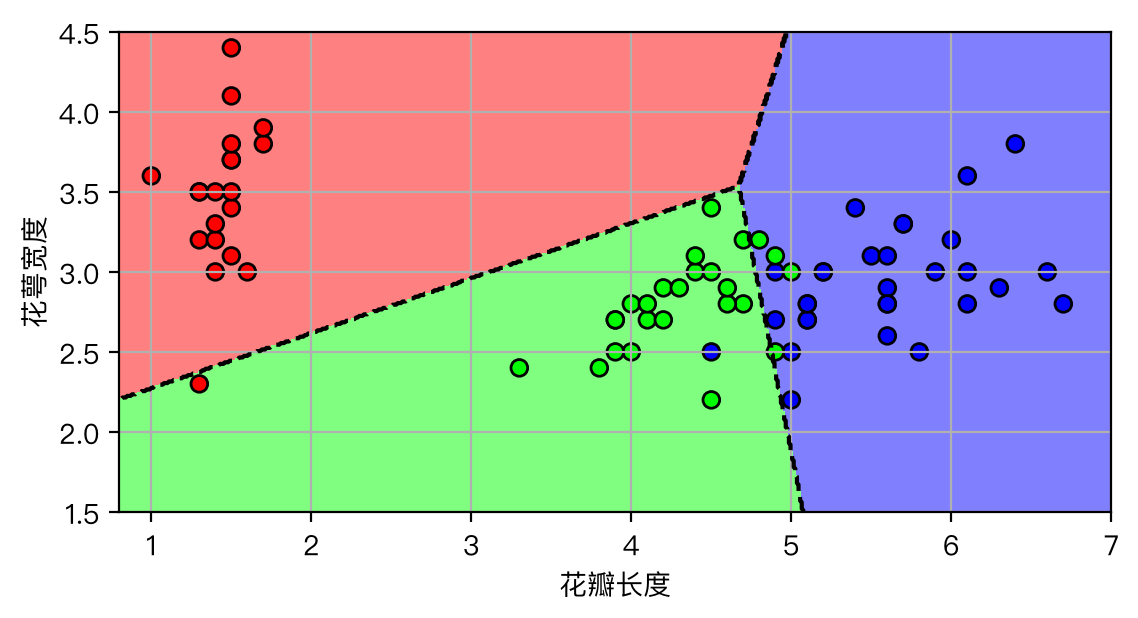

In [45]:
svm3fig

# 非线性决策边界
- 如果数据是可分的，但不是线性可分的，该怎么办？

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>输入空间中无法用直线分开的数据，可能在变换后的空间中变得线性可分。</div>


In [46]:
nlfig = plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
# 第一类：异或（XOR）
X1,Y1 = datasets.make_blobs(n_samples=100, 
         centers=array([[5,5],[-5,-5],[-5, 5], [5, -5]]), cluster_std=0.5, n_features=2, 
         random_state=4487)
Y1 = (Y1>=2)+0
plt.scatter(X1[:,0], X1[:,1], c=Y1, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])

# 第二类：分段
X2,Y2 = datasets.make_blobs(n_samples=100, 
         centers=array([[5],[-5],[0]]), cluster_std=0.5, n_features=1, 
         random_state=4487)
Y2 = (Y2>1)+0
plt.subplot(1,3,2)
plt.scatter(X2[:,0], zeros(X2.shape), c=Y2, cmap=mycmap, edgecolors='k')
plt.xlabel('$x$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])


# 第三类：双月牙
X3,Y3 = datasets.make_moons(n_samples=100,
                                             noise=0.1, random_state=4487)
plt.subplot(1,3,3)
plt.scatter(X3[:,0], X3[:,1], c=Y3, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])
plt.close()

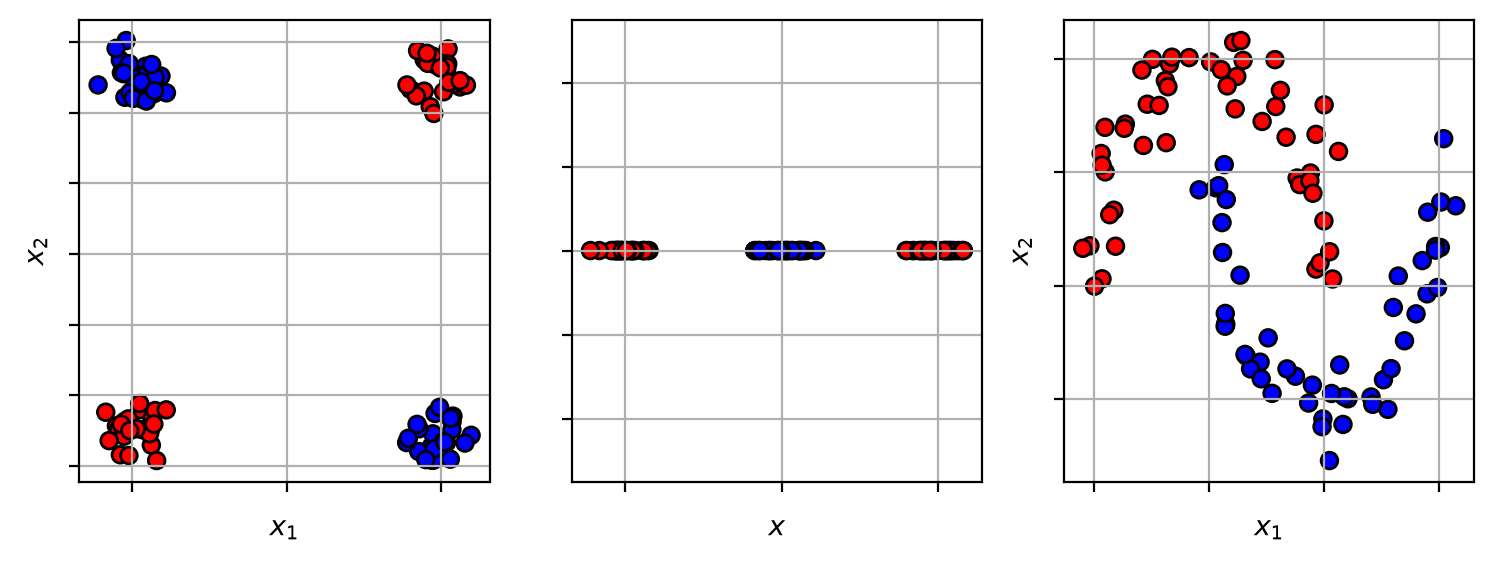

In [47]:
nlfig

# 思路：变换输入空间
- 将输入空间中的 $\mathbf{x} \in \mathbb{R}^d$ 映射到新的高维空间 $\mathbf{z} \in \mathbb{R}^D$：
  - $\mathbf{z} = \Phi(\mathbf{x})$，其中 $\Phi(\mathbf{x})$ 是变换函数。
- 在新空间中学习线性分类器：
  - 如果新空间维度足够高（$D>d$），数据可能在新空间中线性可分。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>特征变换把非线性结构编码到新坐标中，使线性分类器能够表达曲线边界。</div>


In [48]:
nl2fig = plt.figure(figsize=(9,7))

# 第一类：异或（XOR）
plt.subplot2grid((5,3),(0,0), rowspan=2)
plt.scatter(X1[:,0], X1[:,1], c=Y1, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])

X1t = X1[:,0]*X1[:,1]

plt.subplot2grid((5,3),(2,0))
plt.annotate("", xy=(0, -1), xytext=(0,0.8), 
             arrowprops=dict(arrowstyle='Fancy,head_width=3,tail_width=2,head_length=2'))
plt.text(0.2,0,"$\Phi(\mathbf{x}) = x_1*x_2$", fontsize=14)
plt.axis([-1, 1, -1, 1])
plt.axis('off')

plt.subplot2grid((5,3),(3,0), rowspan=2)
plt.scatter(X1t, zeros(X1t.shape), c=Y1, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1 x_2$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])
plt.plot([0,0],[-0.5,0.5], 'k-', lw=2)

# 第二类：分段
plt.subplot2grid((5,3),(0,1), rowspan=2)
plt.scatter(X2[:,0], zeros(X2.shape), c=Y2, cmap=mycmap, edgecolors='k')
plt.xlabel('$x$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])


plt.subplot2grid((5,3),(2,1))
plt.annotate("", xy=(0, -1), xytext=(0,0.8), 
             arrowprops=dict(arrowstyle='Fancy,head_width=3,tail_width=2,head_length=2'))
plt.text(0.2,0,"$\Phi(\mathbf{x}) = [x, x^2]$", fontsize=14)
plt.axis([-1, 1, -1, 1])
plt.axis('off')


X2t = c_[X2, X2**2]
plt.subplot2grid((5,3),(3,1), rowspan=2)
plt.scatter(X2t[:,0], X2t[:,1], c=Y2, cmap=mycmap, edgecolors='k')
plt.xlabel('$x$'); plt.ylabel('$x^2$');plt.grid(True)
plt.plot([-8,8],[10,10], 'k-', lw=2)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])

# 第三类：双月牙
plt.subplot2grid((5,3),(0,2), rowspan=2)
plt.scatter(X3[:,0], X3[:,1], c=Y3, cmap=mycmap, edgecolors='k')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$'); plt.grid(True)
plt.gca().xaxis.set_ticklabels([])
plt.gca().yaxis.set_ticklabels([])

plt.subplot2grid((5,3),(2,2))
plt.annotate("", xy=(0, -1), xytext=(0,0.8), 
             arrowprops=dict(arrowstyle='Fancy,head_width=3,tail_width=2,head_length=2'))
plt.text(0.2,0,"$\Phi(\mathbf{x})$", fontsize=14)
plt.axis([-1, 1, -1, 1])
plt.axis('off')

plt.subplot2grid((5,3),(3,2), rowspan=2)
plt.arrow(0,0, 10,0, lw=2, head_width=1)
plt.arrow(0,0, 0,10, lw=2, head_width=1)
plt.arrow(0,0, -7,-7, lw=2, head_width=1)

X3t,Y3t = datasets.make_blobs(n_samples=100, 
          centers=array([[-5,5],[5,-5]]), cluster_std=2, n_features=2, 
          random_state=4487)
plt.scatter(X3t[:,0], X3t[:,1], c=Y3t, cmap=mycmap, edgecolors='k')
plt.fill([5, -5, -5, 5], [10, 2, -7, 1], alpha=0.5, color='gray', ls='solid')
plt.axis([-10, 12, -10, 12])
plt.text(-10,-12,"高维特征空间")
plt.axis('off')

plt.close()

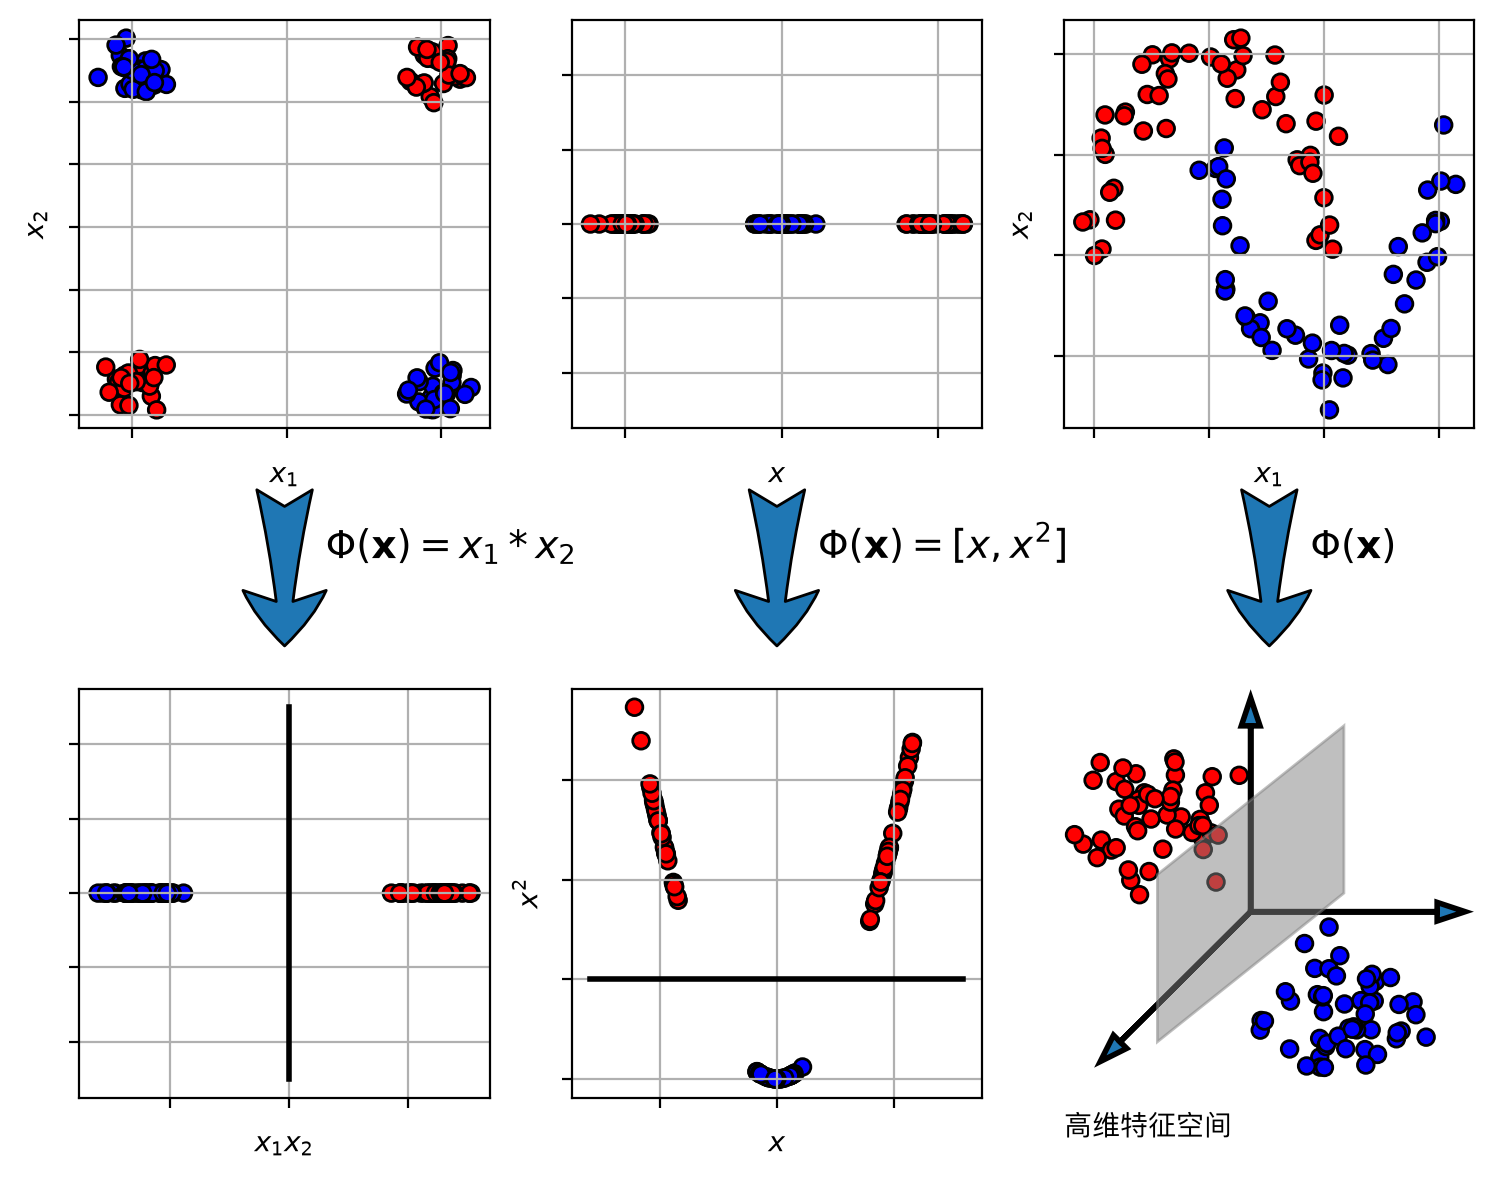

In [49]:
nl2fig

# 核函数
- SVM 对偶问题完全由高维特征向量之间的内积 $\Phi(\mathbf{x}_i)^T \Phi(\mathbf{x}_j)$ 表示。
- 因此不必显式计算高维向量 $\Phi(\mathbf{x}_i)$：
  - 只需计算两个高维特征向量的内积。
- 将它定义为**核函数**：
  - $k(\mathbf{x}_i, \mathbf{x}_j) = \Phi(\mathbf{x}_i)^T \Phi(\mathbf{x}_j)$。
  - 直接计算核通常比显式计算高维特征再求内积更便宜。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>核函数直接给出变换后的内积，避免真正构造可能极高维的特征向量。</div>


# 示例：多项式核
- 输入向量 $\mathbf{x}=\left[\begin{matrix}x_1\\\vdots\\x_d\end{matrix}\right]\in\mathbb{R}^d$。
- 两个向量之间的 $p$ 次多项式核：
  - $k(\mathbf{x},\mathbf{x}') = (\mathbf{x}^T\mathbf{x}')^p = (\sum_{i=1}^d x_i x_i')^p$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>多项式核隐式引入了特征的高阶项和交互项。</div>


- 例如，当 $p=2$ 时：
  $$\begin{align}k(\mathbf{x},\mathbf{x}') &= (\mathbf{x}^T \mathbf{x}')^2 = (\sum_{i=1}^d x_i x_i')^2 \\ &= \sum_{i=1}^d \sum_{j=1}^d (x_ix_i' x_jx_j') = \Phi(\mathbf{x})^T \Phi(\mathbf{x}')\end{align}$$
  - 变换后的特征空间由输入向量的二次项组成：
    $$ \Phi(\mathbf{x}) = \left[\begin{matrix} x_1 x_1 \\ x_1 x_2 \\ \vdots  \\
    x_2 x_1 \\x_2 x_2 \\ \vdots \\
    x_d x_1 \\ \vdots \\ x_d x_d
    \end{matrix}\right]$$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>二次核的显式映射包含所有成对二次项，但核计算无需逐一展开这些特征。</div>


- 乘法次数比较：
  - 直接计算核：$O(d)$。
  - 显式计算变换 $\Phi$：$O(d^2)$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>核技巧的计算优势来自“只计算内积，不显式建立高维向量”。</div>


# 核技巧
- 在优化问题中用核函数替换内积，称为**核技巧**：
  - 它可以将线性分类算法变为非线性分类算法。
  - 决策边界的形状由核函数决定。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>核函数是模型假设的一部分；选择不同的核，等于选择不同的相似性和决策边界形状。</div>


# 核 SVM
- 在线性 SVM 中用核函数替换内积：
  $$\mathop{\mathrm{argmax}}_{\alpha} \sum_i \alpha_i -\frac{1}{2}\sum_{i=1}^N\sum_{j=1}^N \alpha_i\alpha_j y_i y_j k(\mathbf{x}_i, \mathbf{x}_j) \\~~ \mathrm{s.t.} \sum_{i=1}^N \alpha_iy_i = 0, \quad \alpha_i\geq 0$$
- 预测：
  - $y_* = \mathrm{sign}(\sum_{i=1}^N \alpha_i y_i k(\mathbf{x}_i, \mathbf{x}_*) + b)$。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>核 SVM 的训练与预测仍主要由支持向量贡献，只是将普通内积换成核函数。</div>


# 示例：使用多项式核的核 SVM
- 决策边界可以理解为对一个多项式曲面的“切片”。
- 多项式次数越高，决策边界可以越复杂。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>多项式次数过高可提高表达能力，但也可能使边界过度复杂。</div>


In [50]:
inds = (Y3==0)
X4 = X3[inds]
Y4 = Y3[inds]
tmpX,tmpY = datasets.make_blobs(n_samples=20, 
         centers=1, cluster_std=0.2, n_features=2, 
         center_box=(0,0), random_state=4487)
X4 = vstack((X4,tmpX))
Y4 = r_[Y4, tmpY+1]

In [51]:
# 使用不同次数的多项式核拟合 SVM
degs = [2,3,4]

clf = {}
for d in degs:
    clf[d] = svm.SVC(kernel='poly', degree=d, C=100)
    clf[d].fit(X4, Y4)

In [52]:
def plot_posterior_svm(model, axbox, X, phi=None):
    # 网格点
    xr = [ linspace(axbox[0], axbox[1], 200), 
           linspace(axbox[2], axbox[3], 200) ]

    # 创建用于计算决策区域的网格，
    # 然后组成一个大型 [N,2] 矩阵
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allptsx = c_[xgrid0.ravel(), xgrid1.ravel()]

    # 特征变换
    if phi != None:
        allpts = apply_along_axis(phi, 1, allptsx)
    else:
        allpts = allptsx
    
    # 计算决策得分
    score = model.decision_function(allpts).reshape(xgrid0.shape)

    cmap = ([1,0,0], [1,0.7,0.7], [0.7,1,0.7], [0,1,0])
    CS = plt.contourf(xr[0], xr[1], score, colors=cmap, 
                      levels=[-1000, -1, 0, 1, 1000], alpha=0.3)

    plt.contour(xr[0], xr[1], score, levels=[-1, 1], linewidths=1, linestyles='dashed', colors='k')
    plt.contour(xr[0], xr[1], score, levels=[0], linestyles='solid', colors='k')
        
    plt.plot([-100,-100], [-100,-100], 'k-', label='决策边界')
    plt.plot([-100,-100], [-100,-100], 'k--', label='间隔')
    
    plt.plot(X[model.support_,0], X[model.support_,1], 
             'ko',fillstyle='none', markeredgewidth=2, label='支持向量')

    leg = plt.legend(loc='best', fontsize=7)
    leg.get_frame().set_facecolor('white')         
    plt.axis(axbox); plt.grid(True)    

In [53]:
axbox = [-1.5, 1.5, -1.5, 1.5]

polysvmfig = plt.figure(figsize=(9,3))

for (i,d) in enumerate(degs):
    plt.subplot(1,3,i+1)
    plot_posterior_svm(clf[d], axbox, X4)
    plt.scatter(X4[:,0], X4[:,1], c=Y4, cmap=mycmap, edgecolors='k')
    plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])    
    plt.title('多项式次数=' + str(degs[i]))
plt.close()

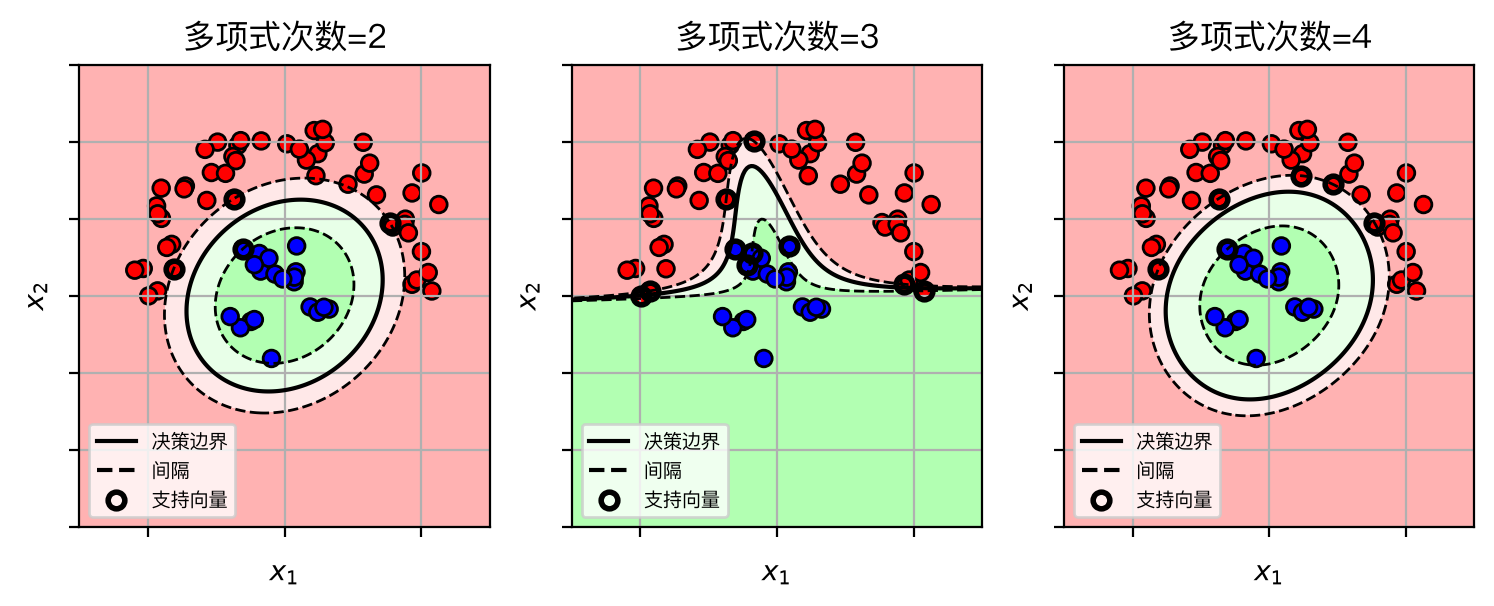

In [54]:
polysvmfig

# RBF 核
- 径向基函数核（RBF 核）：
  - $k(\mathbf{x},\mathbf{x}') = e^{-\gamma\|\mathbf{x}-\mathbf{x}'\|^2}$。
  - 它的形状类似高斯函数。
- $\gamma>0$ 是核的带宽倒数参数，控制函数的平滑度：
  - 较小的 $\gamma$ → 较宽的 RBF → 更平滑的函数。
  - 较大的 $\gamma$ → 较窄的 RBF → 更弯曲的函数。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>gamma 越大，单个样本的影响范围越小，边界通常越弯曲；gamma 越小则边界更平滑。</div>


In [55]:
rbffig = plt.figure()
x = linspace(-10,10,500)
gammas = array([0.1, 1.0, 10.0])
for g in gammas:
    kx = exp(-g*(x**2))
    plt.plot(x, kx, label="$\gamma="+str(g)+"$")
plt.xlabel("$||\mathbf{x}-\mathbf{x}'||$")
plt.ylabel("$k(\mathbf{x},\mathbf{x}')$")
plt.axis([-10, 10, 0, 1.1]); plt.grid(True)
plt.legend()
plt.close()

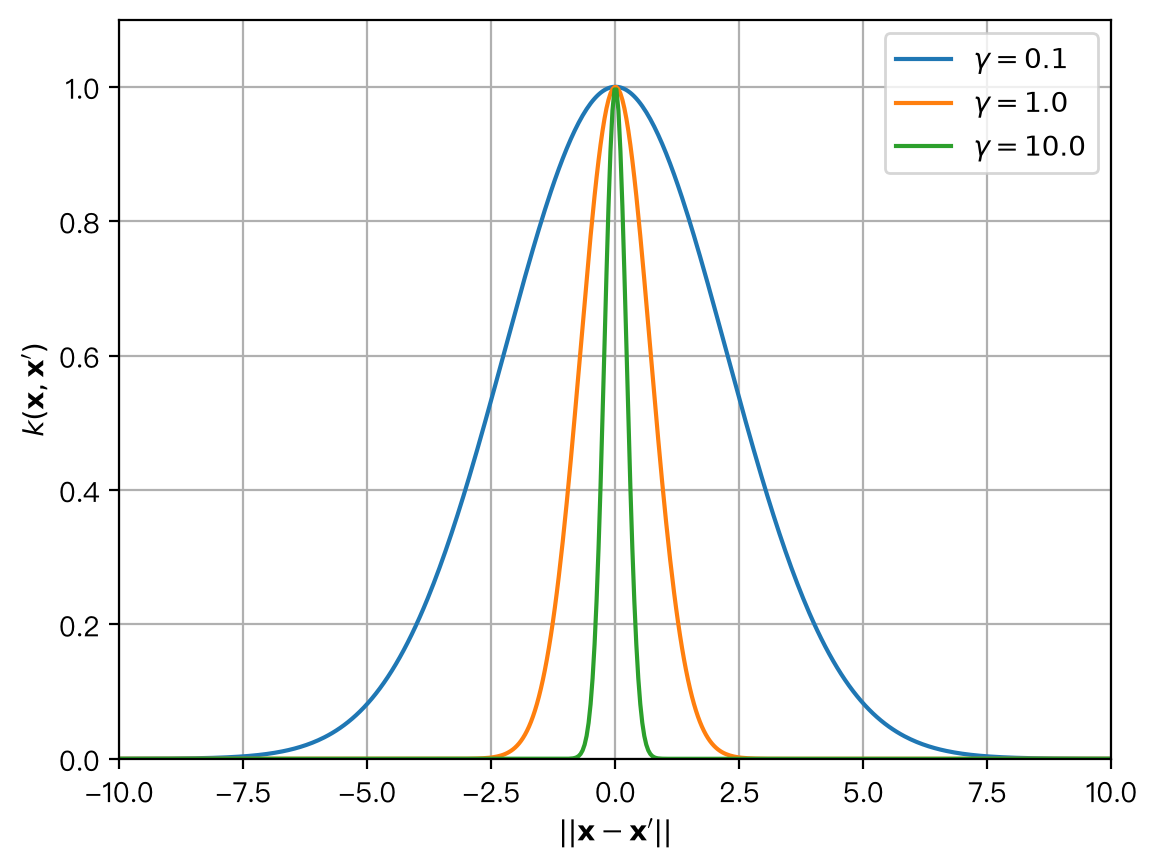

In [56]:
rbffig

# 使用 RBF 核的核 SVM
- 尝试不同的 $\gamma$：
  - 每个 $\gamma$ 都会得到平滑程度不同的决策边界。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>RBF 核可以拟合复杂非线性边界，但 gamma 必须与 C 一起调整。</div>


In [57]:
# 使用 RBF 核拟合 SVM
gammas = [0.1, 1, 25]

clf = {}
for i in gammas:
    clf[i] = svm.SVC(kernel='rbf', gamma=i, C=1000)
    clf[i].fit(X3, Y3)

In [58]:
axbox = [-2, 3, -2, 2]

rbfsvmfig = plt.figure(figsize=(9,3))

for i,x in enumerate(gammas):
    clfx = clf[x]
    plt.subplot(1,3,i+1)

    plot_posterior_svm(clfx, axbox, X3)
    plt.scatter(X3[:,0], X3[:,1], c=Y3, cmap=mycmap, edgecolors='k')
    plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])
    plt.title('RBF $\gamma$=' + str(x))
plt.close()

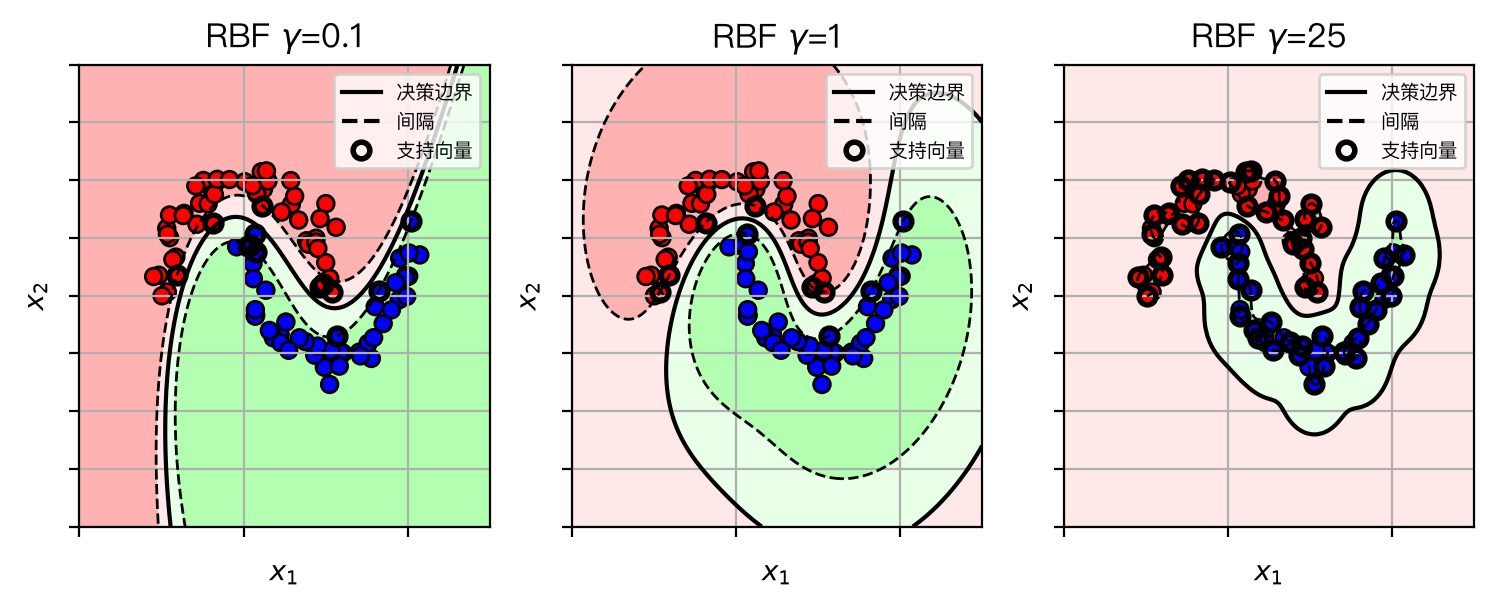

In [59]:
rbfsvmfig

# Iris 数据示例
- 较大的 $\gamma$ 会产生复杂、弯曲的决策边界。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>gamma 过大时，模型可能围绕单个训练点形成局部小区域，产生过拟合。</div>


In [60]:
# 载入 Iris 数据；每行为（花瓣长度、花萼宽度、类别）
irisdata = loadtxt('iris2.csv', delimiter=',', skiprows=1)

X = irisdata[:,0:2]  # 前两列是特征（花瓣长度、花萼宽度）
Y = irisdata[:,2]    # 第三列是类别标签（变色鸢尾=1，弗吉尼亚鸢尾=2）

print(X.shape)

(100, 2)


In [61]:
# 随机将数据划分为 50% 训练集和 50% 测试集
trainX, testX, trainY, testY = \
  model_selection.train_test_split(X, Y, 
  train_size=0.5, test_size=0.5, random_state=4487)

print(trainX.shape)
print(testX.shape)

(50, 2)
(50, 2)


In [62]:
# 使用 RBF 核拟合 SVM
gammas = [0.1, 1, 10]

clf = {}
for i in gammas:
    clf[i] = svm.SVC(kernel='rbf', gamma=i, C=100)
    clf[i].fit(trainX, trainY)

irbffig = plt.figure(figsize=(9,3))
axbox = [2.5, 7, 1.5, 4]
for i,x in enumerate(gammas):
    plt.subplot(1,3,i+1)
    plot_posterior_svm(clf[x], axbox, trainX)
    plt.scatter(trainX[:,0],trainX[:,1],c=trainY, cmap=mycmap, edgecolors='k')
    plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])
    plt.title('RBF $\gamma$=' + str(x))
plt.close()

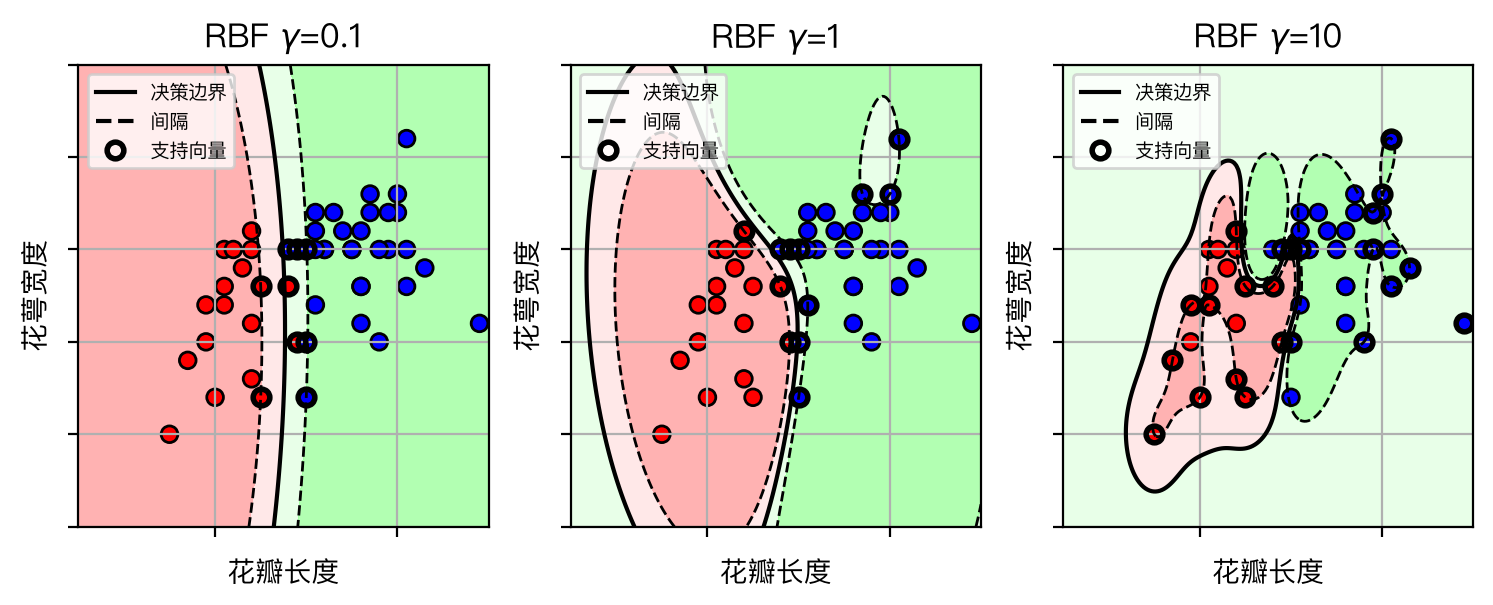

In [63]:
irbffig

# 如何选择最优核参数？
- 对候选核参数 $\gamma$ 和 SVM 参数 $C$ 进行交叉验证。
  - 候选参数很多时，网格搜索的计算代价可能很高。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>对 C 和 gamma 做网格搜索时常在对数尺度上选候选值，例如 0.01、0.1、1、10、100。</div>


In [64]:
# 设置待尝试的参数列表
paramgrid = {'C': logspace(-2,3,20), 
             'gamma': logspace(-4,3,20) }

print(paramgrid)

# 设置交叉验证对象
# 传入使用 RBF 核的 SVM、参数网格和交叉验证折数
svmcv = model_selection.GridSearchCV(svm.SVC(kernel='rbf'), paramgrid, cv=5,
                                    n_jobs=-1, verbose=True)

# 运行交叉验证（对每次划分进行训练）
svmcv.fit(trainX, trainY);

print("最优参数：", svmcv.best_params_)

{'C': array([1.00000000e-02, 1.83298071e-02, 3.35981829e-02, 6.15848211e-02,
       1.12883789e-01, 2.06913808e-01, 3.79269019e-01, 6.95192796e-01,
       1.27427499e+00, 2.33572147e+00, 4.28133240e+00, 7.84759970e+00,
       1.43844989e+01, 2.63665090e+01, 4.83293024e+01, 8.85866790e+01,
       1.62377674e+02, 2.97635144e+02, 5.45559478e+02, 1.00000000e+03]), 'gamma': array([1.00000000e-04, 2.33572147e-04, 5.45559478e-04, 1.27427499e-03,
       2.97635144e-03, 6.95192796e-03, 1.62377674e-02, 3.79269019e-02,
       8.85866790e-02, 2.06913808e-01, 4.83293024e-01, 1.12883789e+00,
       2.63665090e+00, 6.15848211e+00, 1.43844989e+01, 3.35981829e+01,
       7.84759970e+01, 1.83298071e+02, 4.28133240e+02, 1.00000000e+03])}
Fitting 5 folds for each of 400 candidates, totalling 2000 fits
最优参数： {'C': np.float64(0.37926901907322497), 'gamma': np.float64(0.4832930238571752)}


In [65]:
# 显示前 25 组参数的交叉验证得分
N = 25
for m,p in zip(svmcv.cv_results_['mean_test_score'][0:N], svmcv.cv_results_['params'][0:N]):
    print("平均得分={:.4f} {}".format(m,p))

平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.0001)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.00023357214690901214)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.000545559478116852)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.0012742749857031334)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.002976351441631319)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.0069519279617756054)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.01623776739188721)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.0379269019073225)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.08858667904100823)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.2069138081114788)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(0.4832930238571752)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(1.1288378916846884)}
平均得分=0.6200 {'C': np.float64(0.01), 'gamma': np.float64(2.63665089873035

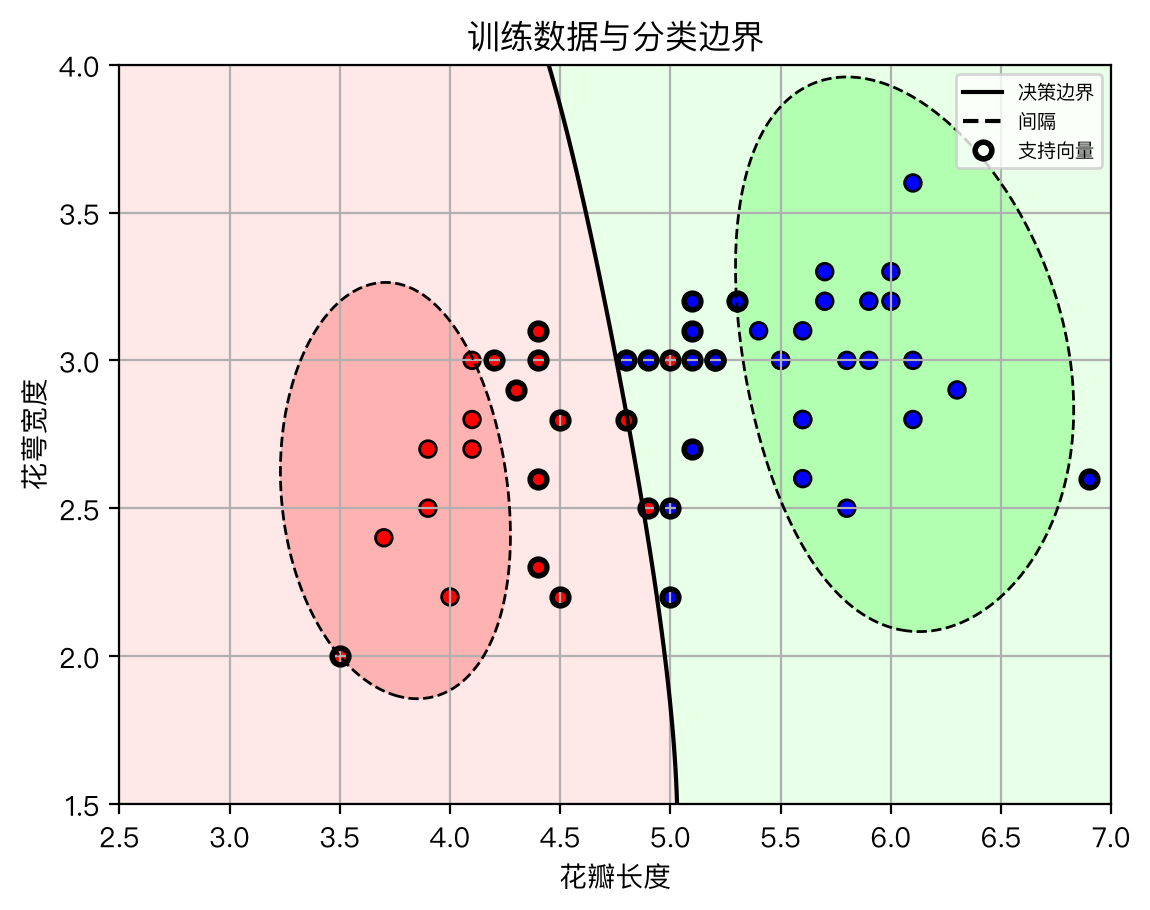

In [66]:
# 显示分类器与训练数据
plt.figure()
plot_posterior_svm(svmcv.best_estimator_, axbox, trainX)
plt.scatter(trainX[:,0], trainX[:,1], c=trainY, cmap=mycmap, edgecolors='k')
plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
plt.title('训练数据与分类边界');
plt.show()

In [67]:
# 使用模型进行预测
predY = svmcv.predict(testX)

# 计算准确率
acc      = metrics.accuracy_score(testY, predY)
print("测试准确率 =", acc)

测试准确率 = 0.88


# 自定义核函数
- 可以使用任意满足**半正定**条件的核函数：
  1. 它可写成某个特征变换的内积：$k(\mathbf{x}_1,\mathbf{x}_2) = \langle \Phi(\mathbf{x}_1), \Phi(\mathbf{x}_2) \rangle$。
  2. 对任意大小、任意可能的数据集 $\mathbf{X}$，核矩阵 $K=[k(\mathbf{x}_i,\mathbf{x}_j)]_{i,j}$ 都是半正定矩阵。
    - 当且仅当 $\mathbf{z}^T\mathbf{K}\mathbf{z} \geq 0, \forall \mathbf{z}$ 时，$\mathbf{K}$ 为半正定矩阵。
- 在 scikit-learn 中，可将一个可调用函数传给 `kernel` 参数。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>不是任意“相似度函数”都能作为 SVM 核；半正定性保证它对应某个特征空间的内积。</div>


## 示例：拉普拉斯核
- $k(\mathbf{x}_1,\mathbf{x}_2) = \exp(-\alpha ||\mathbf{x}_1 - \mathbf{x}_2||)$

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>拉普拉斯核使用普通欧氏距离，而 RBF 核的指数中使用平方欧氏距离。</div>


In [68]:
from scipy import spatial

# 创建自定义核函数
# 拉普拉斯核：exp(-alpha*||x1-x2||)
def mykernel(X1, X2, alpha=1.0):
    # X1、X2 分别是 N1×d 和 N2×d 矩阵，每行是一个 d 维向量
    # alpha 是超参数
    
    # 计算两组样本之间的成对欧氏距离
    D = spatial.distance.cdist(X1, X2, metric='euclidean')
    
    # 返回核矩阵
    return exp(-alpha*D)

In [69]:
alphas = [0.1, 1., 10.]

clf = {}
for i in alphas:
    # 使用当前 alpha 创建临时核函数
    tmpkern = lambda X1,X2,alpha=i: mykernel(X1,X2,alpha=alpha)
    
    # 创建使用自定义核函数的 SVM
    clf[i] = svm.SVC(kernel=tmpkern, C=100)
    clf[i].fit(trainX, trainY)

In [70]:
ilapfig = plt.figure(figsize=(9,3))
axbox = [2.5, 7, 1.5, 4]
for i,x in enumerate(alphas):
    plt.subplot(1,3,i+1)
    plot_posterior_svm(clf[x], axbox, trainX)
    plt.scatter(trainX[:,0],trainX[:,1],c=trainY, cmap=mycmap, edgecolors='k')
    plt.xlabel('花瓣长度'); plt.ylabel('花萼宽度')
    plt.gca().xaxis.set_ticklabels([])
    plt.gca().yaxis.set_ticklabels([])
    plt.title('拉普拉斯核 $\\alpha$=' + str(x))
plt.close()

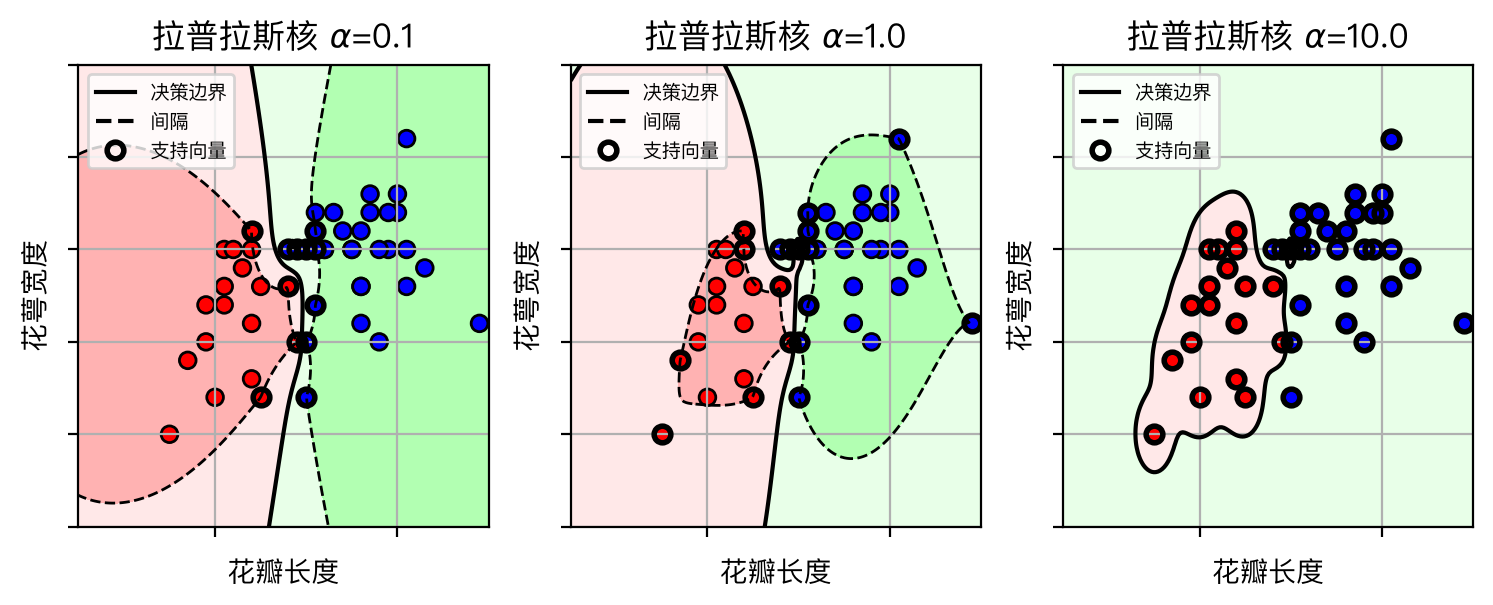

In [71]:
ilapfig

# SVM 总结
- **线性 SVM：**
  - 使用线性函数 $f(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + b$。
  - 给定新样本 $\mathbf{x}_*$，预测 $y_* = \mathrm{sign}(f(\mathbf{x}_*))$。
- **核 SVM：**
  - 核函数决定非线性决策边界的形状。
    - 它隐式地将输入特征变换到高维空间。
    - 在高维空间中使用线性分类器。
    - 在原输入空间中得到非线性决策边界。
- **训练：**
  - 最大化训练数据的间隔，即最大化样本与决策面之间的分离程度。
  - 使用交叉验证选择超参数 $C$ 及核函数的超参数。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.6em;"><b>小结：</b>复习时要把三个参数作用分清：C 控制违反惩罚，kernel 决定相似性形式，gamma 控制 RBF 的影响范围。</div>


# 本讲总体总结

1. **SVM 的核心是最大间隔。** 它不直接学习类别概率，而是寻找与最近训练样本距离最大的决策边界。
2. **支持向量决定决策边界。** 在对偶解中，只有乘子非零的训练样本直接参与预测。
3. **硬间隔适用于线性可分数据，软间隔适用于真实含噪数据。** 软间隔通过松弛变量允许部分样本进入间隔或被错分。
4. **C 控制违反间隔的惩罚。** C 大时更强调拟合训练数据；C 小时允许更多违反，通常得到更宽、更平滑的间隔。
5. **合页损失只惩罚间隔内和分类错误的样本。** 位于间隔正确一侧的样本损失为零。
6. **对偶形式是核方法的桥梁。** 因为对偶问题只使用样本之间的内积，所以可以直接用核函数替换内积。
7. **核技巧让线性 SVM 获得非线性决策边界。** 多项式核隐式引入高阶交互特征；RBF 核根据样本间距离建立局部相似性。
8. **gamma 控制 RBF 核的影响范围。** gamma 大时边界更局部、更弯曲；gamma 小时边界更平滑。
9. **超参数必须在训练集内部选择。** 对 C、gamma、核类型和多项式次数进行交叉验证，最终测试集只用于模型确定后的评估。
10. **多类 SVM 由多个二元 SVM 组合而成。** 一对一训练所有类别对；一对其余为每个类别训练一个分类器。

<div style="font-size: 0.88em; color: #5f6368; border-left: 3px solid #9aa0a6; padding: 0.25em 0.75em; margin-top: 0.8em;"><b>小结：</b>用一句话记忆本讲：SVM 用支持向量确定最大间隔边界，再通过核函数将这一思想扩展到非线性分类。</div>
